# Revision TA Session 22-05-26

# Assignments 7
### Concepts, metrics, and observations from given solutions

| Section | Topic | From |
|---------|-------|------|
| 1 | Why do we split data at all? | Q1 |
| 2 | What does `model.score` actually return? (R²) | Q1 |
| 3 | Cross-validation — why bother? | Q3 |
| 4 | Polynomial features — what changes and what doesn't | Q4–Q5 |
| 5 | Validation curves — reading the bias-variance story | Q8–Q9 |
| 6 | The confusion matrix and the four metrics | Q11 |
| 7 | ROC and AUC — what the curve is really showing | Q11 |

---

## Section 1 — Why do we split data? (Q1)

This is the first thing Q1 asked you to do:

Intercept: 0.05982915458424243
Slope: [4.16104394]
Test R^2 score: 0.9910376250573891


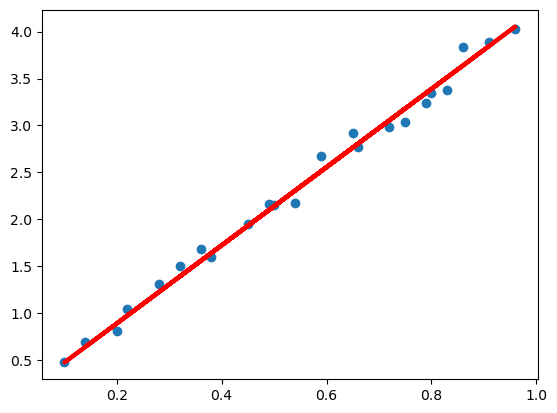

In [1]:
# From Assignment 7, Q1
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

el, t = np.loadtxt('data/pendulum.txt', unpack=True)
tsq = t*t
l = el.reshape(-1, 1)

l_train, l_test, tsq_train, tsq_test = train_test_split(l, tsq, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(l_train, tsq_train)

pred_t = model.predict(l_test)
plt.scatter(l_test, tsq_test)
plt.plot(l_test, pred_t, 'r', lw=3);

print("Intercept:", model.intercept_)
print("Slope:", model.coef_)

score = model.score(l_test, tsq_test)
print("Test R^2 score:", score)

### 💬 Discussion

**Why not just fit on all the data and report that error?**  
A model that was trained on a data point has already "seen" it, so its error on that point is artificially low — the model may have memorised it rather than learning the pattern. The test set consists of points the model has never seen during training, so the error there is an honest estimate of how it will behave on new data in the real world.

**Notice `random_state=42`.** The split is random. If you changed this number you'd get a different set of training points, and potentially a slightly different score. That's why Q3 asks you to use cross-validation — to make the score less dependent on any one lucky or unlucky split.

> **Ask the class:** If you scored the model on the *training* data instead of the test data, would the R² be higher or lower than on the test data? Why?

---
## Section 2 — What does `model.score` return? (Q1)

Q1 asked you to "calculate the error on the test data using `model.score`". That score is **R²**, the coefficient of determination:

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

- The **numerator** is your model's residual error — how much it got wrong.
- The **denominator** is the total variance in $y$ — how spread out the data is.
- So R² = 1 − (fraction of variance your model *failed* to explain).

**Three reference points:**
- **R² = 1.0** → perfect predictions, zero residual error.
- **R² = 0.0** → your model does no better than always predicting the mean $\bar{y}$.
- **R² < 0** → your model is *worse* than just predicting the mean — this can happen on test data when the model has overfit.

**Important:** R² is not the fraction of points predicted correctly. That is *accuracy* — a completely different metric for classification. R² is specific to regression.

> **Ask the class:** The pendulum data has a very high R² (close to 1). Does a high R² always mean the model has found the correct physical relationship? What else should you look at? *(Think: the slope and intercept — do they match the physical formula $T^2 = \frac{4\pi^2}{g} l$?)*

---
## Section 3 — Cross-validation: why bother? (Q3)

In [2]:
# From Assignment 7, Q3
from sklearn.model_selection import cross_val_score

tsq = t*t
l = el.reshape(-1, 1)
scores = cross_val_score(model, l, tsq, cv=4)

print("Cross-validation scores:", scores)

Cross-validation scores: [0.94132986 0.91703981 0.85374095 0.87361618]


### 💬 Discussion

With `cv=4`, the data is split into 4 equal folds. The model is trained 4 separate times — each time on 3 folds, tested on the remaining 1. You get 4 independent R² scores.

**Why is this better than a single split?**  
A single 75/25 split is one "roll of the dice" — you might have gotten an easy test set or a hard one. Cross-validation averages over 4 different held-out sets, so the mean score is a much more stable estimate. The spread of the 4 scores also tells you how sensitive the model is to which data ends up in the test set.

**The extreme case** is `cv=N` (Leave-One-Out cross-validation, where N is the dataset size). Each point gets to be the test set exactly once. This gives the most stable estimate but is expensive to compute for large datasets.

> **Ask the class:** The 4 scores you see are probably all close to each other. What would it mean if they varied wildly — say from 0.6 to 0.99?

---
## Section 4 — Polynomial features: what changes and what doesn't (Q4 & Q5)

In [3]:
# From Assignment 7, Q4
from sklearn.preprocessing import PolynomialFeatures
el, t = np.loadtxt('data/pendulum.txt', unpack=True)

t = t.reshape(-1, 1)
poly = PolynomialFeatures(degree=2, include_bias=False)
t_poly = poly.fit_transform(t)

t_poly_train, t_poly_test, el_train, el_test = train_test_split(t_poly, el, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(t_poly_train, el_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

score = model.score(t_poly_test, el_test)
print("Test R^2 score:", score)

Intercept: 0.02034830412415345
Coefficients: [-0.04772925  0.25568951]
Test R^2 score: 0.991109205062407


In [4]:
# From Assignment 7, Q5 — the pipeline approach
from sklearn.pipeline import make_pipeline

el, t = np.loadtxt('data/pendulum.txt', unpack=True)
t = t.reshape(-1, 1)

model = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())

t_train, t_test, el_train, el_test = train_test_split(t, el, test_size=0.25, random_state=42)

model.fit(t_train, el_train)

score = model.score(t_test, el_test)
print("Test R^2 score:", score)

lin_reg = model.named_steps['linearregression']
print("Intercept:", lin_reg.intercept_)
print("Coefficients:", lin_reg.coef_)

Test R^2 score: 0.991109205062407
Intercept: 0.02034830412415345
Coefficients: [-0.04772925  0.25568951]


### 💬 Discussion

**What does `PolynomialFeatures(degree=2)` actually do?**  
Given input $t$, it creates the feature vector $[t, t^2]$. The `LinearRegression` then fits $l = c_0 + c_1 t + c_2 t^2$. The model is still *linear in the coefficients* — it's linear regression, not a non-linear model. The non-linearity is in the *features*, not the model itself.

**Q4 vs Q5 — same result, different structure.** In Q4 you manually transformed the data before passing it in. In Q5, `make_pipeline` chains the steps so the transformation and the fit happen together. The R² is identical — but the pipeline is safer in practice. Why? Because in Q4, if you forgot to apply `poly.transform` on the test set (or accidentally called `fit_transform` instead of `transform` on test data), you'd get wrong or leaked results. The pipeline applies the same fitted transformation automatically.

**Notice `fit_transform` vs `transform`:**  
- `fit_transform(X_train)` — learns the polynomial feature names from training data, then transforms it.
- `transform(X_test)` — applies the *already learned* transformation to test data. You must never call `fit_transform` on test data — that would be fitting to information you're not supposed to have.

> **Ask the class:** In A9, the same polynomial approach was applied to Logistic Regression. Looking at the results, the polynomial LR achieved *identical* test accuracy to plain LR (87.33%). What does that tell you about the shape of the decision boundaries in the data?

---
## Section 5 — Validation curves: reading the bias-variance story (Q8 & Q9)

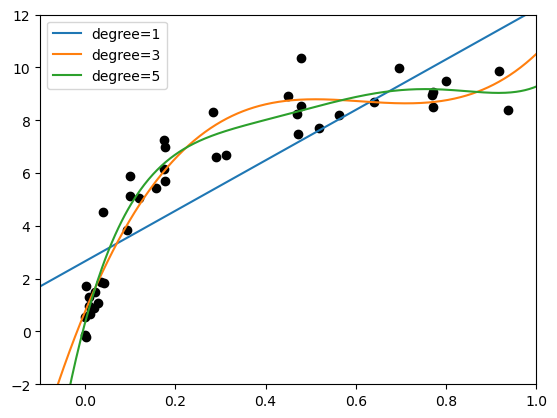

In [5]:
# From Assignment 7, Q8
from sklearn.model_selection import validation_curve
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

def make_data(N, err=1.0, rseed=1):
    rng = np.random.RandomState(rseed)
    X = rng.rand(N, 1) ** 2
    y = 10 - 1. / (X.ravel() + 0.1)
    if err > 0:
        y += err * rng.randn(N)
    return X, y

def PolynomialRegression(degree=2, **kwargs):
    return make_pipeline(PolynomialFeatures(degree), LinearRegression(**kwargs))

X, y = make_data(40)

X_test_line = np.linspace(-0.1, 1.1, 500)[:, None]

plt.scatter(X.ravel(), y, color='black')
axis = plt.axis()
for degree in [1, 3, 5]:
    y_test_line = PolynomialRegression(degree).fit(X, y).predict(X_test_line)
    plt.plot(X_test_line.ravel(), y_test_line, label='degree={0}'.format(degree))
plt.xlim(-0.1, 1.0)
plt.ylim(-2, 12)
plt.legend(loc='best');

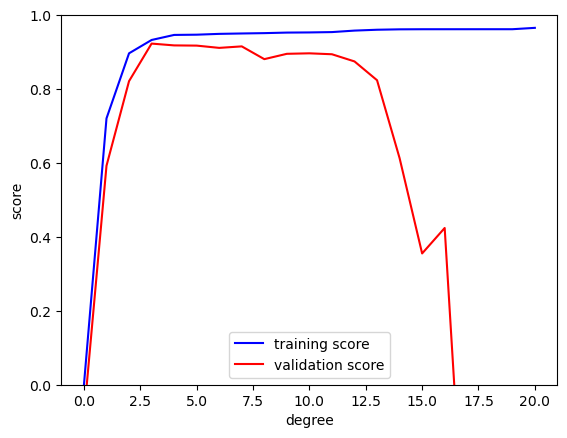

In [6]:
# From Assignment 7, Q8 continued — the validation curve
degree = np.arange(0, 21)
train_score, val_score = validation_curve(
    PolynomialRegression(), X, y,
    param_name='polynomialfeatures__degree',
    param_range=degree,
    cv=7
)

plt.plot(degree, np.median(train_score, 1), color='blue', label='training score')
plt.plot(degree, np.median(val_score, 1), color='red', label='validation score')
plt.legend(loc='best')
plt.ylim(0, 1)
plt.xlabel('degree')
plt.ylabel('score');

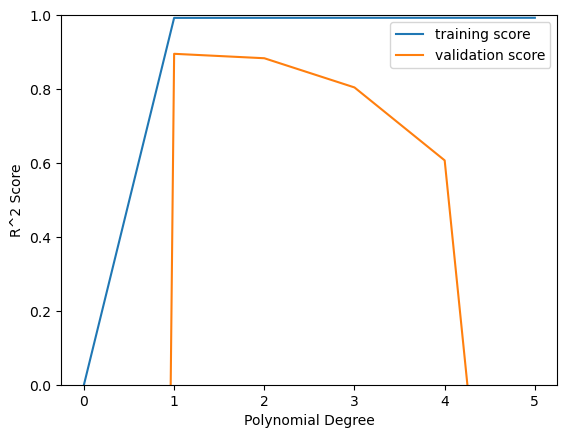

In [7]:
# From Assignment 7, Q9 — same curve on the pendulum data
el, t = np.loadtxt('data/pendulum.txt', unpack=True)
X_pend = el.reshape(-1, 1)
y_pend = t * t

degree = np.arange(0, 6)

train_score, val_score = validation_curve(
    PolynomialRegression(), X_pend, y_pend,
    param_name='polynomialfeatures__degree',
    param_range=degree,
    cv=4
)

plt.plot(degree, np.median(train_score, axis=1), label='training score')
plt.plot(degree, np.median(val_score, axis=1), label='validation score')
plt.xlabel('Polynomial Degree')
plt.ylabel('R^2 Score')
plt.legend(loc='best')
plt.ylim(0, 1)
plt.show()

### 💬 Discussion

**Reading the validation curve — the three zones:**

| Zone | Training score | Validation score | Diagnosis |
|------|---------------|------------------|-----------|
| Low degree | Low | Low | **Underfitting (high bias)** — model too simple |
| Sweet spot | High | High (peak) | **Good generalisation** |
| High degree | High | Drops | **Overfitting (high variance)** — model memorises training noise |

**Q8 vs Q9 — compare the two curves.** The synthetic data from Q8 needs a degree of about 3–4 before the validation score peaks and then degrades. The pendulum data plateaus at degree 1–2 and stays flat — it doesn't overfit even at degree 5. Why? Because the pendulum's true relationship ($T^2 \propto l$) is genuinely linear. More polynomial terms don't hurt because the data is clean and the real pattern was already captured.

**The gap between the two curves** at high degree is what tells you about overfitting. When the training score is 1.0 and the validation score has collapsed, the model has memorised the training points exactly but generalises poorly.

> **Ask the class:** In Q9, why does the validation score stay high and not drop even at degree 5? If you had very noisy pendulum data (large measurement errors), what would the curve look like at high degree?

---
## Section 6 — The confusion matrix and the four metrics (Q11)


=== Training Data ===
  Accuracy  : 0.9437
  Precision : 0.9231
  Recall    : 0.9600
  F1-Score  : 0.9412

=== Test Data ===
  Accuracy  : 0.9500
  Precision : 1.0000
  Recall    : 0.9200
  F1-Score  : 0.9583


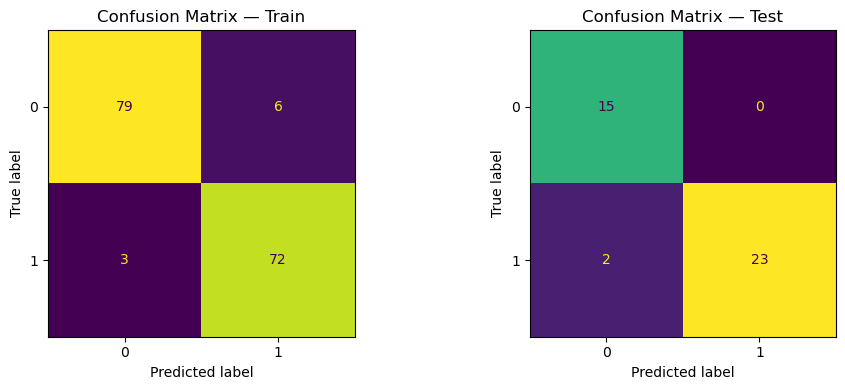

In [8]:
# From Assignment 7, Q11
from sklearn.datasets import make_blobs
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, RocCurveDisplay
)

X_blob, y_blob = make_blobs(n_samples=200, centers=2, cluster_std=1.2, random_state=0)

X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_blob, y_blob, test_size=0.2, random_state=42)

gnb = GaussianNB()
gnb.fit(X_b_train, y_b_train)

y_train_pred  = gnb.predict(X_b_train)
y_test_pred   = gnb.predict(X_b_test)
y_train_proba = gnb.predict_proba(X_b_train)[:, 1]
y_test_proba  = gnb.predict_proba(X_b_test)[:, 1]

def print_metrics(y_true, y_pred, split_name):
    print(f"\n=== {split_name} ===")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred):.4f}")

print_metrics(y_b_train, y_train_pred, 'Training Data')
print_metrics(y_b_test,  y_test_pred,  'Test Data')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_true, y_pred, title in zip(
    axes,
    [y_b_train, y_b_test],
    [y_train_pred, y_test_pred],
    ['Confusion Matrix — Train', 'Confusion Matrix — Test']
):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

### 💬 Discussion

**Start from the confusion matrix — every metric lives inside it.**

The four cells are: True Positives (TP), True Negatives (TN), False Positives (FP), False Negatives (FN).

| Metric | Formula | The question it answers |
|--------|---------|------------------------|
| **Accuracy** | (TP+TN) / all | What fraction did I get right overall? |
| **Precision** | TP / (TP+FP) | Of everything I *called* positive, how many truly were? |
| **Recall** | TP / (TP+FN) | Of all *actual* positives, how many did I catch? |
| **F1** | 2·P·R / (P+R) | Balanced score — penalises if either P or R is low |

**When does precision matter more than recall?**  
When false positives are expensive — e.g. a spam filter that moves real emails to spam. You want high precision: when you say "spam", you want to be sure.

**When does recall matter more than precision?**  
When false negatives are expensive — e.g. a cancer screening test. Missing a real tumour (false negative) is far worse than flagging someone who turns out to be healthy (false positive). You want high recall: catch everyone who actually has cancer.

**Why F1?** If you optimise only for precision you can get 100% by only ever predicting positive when you're absolutely certain — but you'll miss most real positives. If you optimise only for recall you can get 100% by predicting positive every single time — but your precision collapses. F1 penalises either extreme.

> **Ask the class:** Look at the confusion matrix from your test data. Find the FP and FN cells. If this classifier were used as a medical diagnostic tool, which of those errors is more serious — and how would you adjust the model to reduce it?

---
## Section 7 — ROC and AUC: what the curve is really showing (Q11)

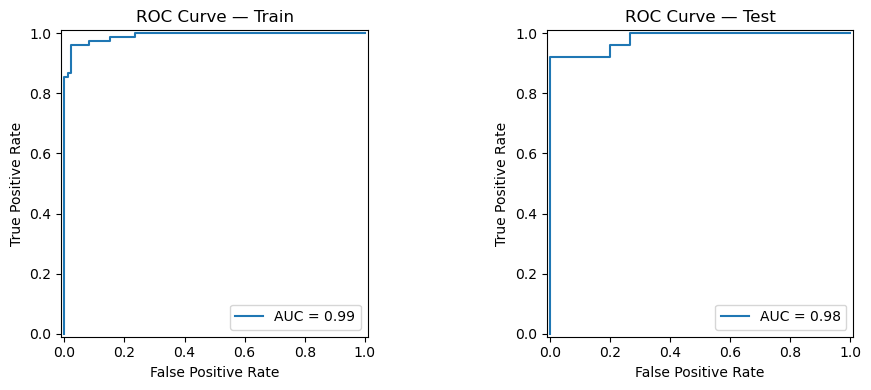

In [9]:
# From Assignment 7, Q11 — ROC curves
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_true, y_proba, title in zip(
    axes,
    [y_b_train, y_b_test],
    [y_train_proba, y_test_proba],
    ['ROC Curve — Train', 'ROC Curve — Test']
):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot(ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

### 💬 Discussion

**What is the ROC curve actually plotting?**

A classifier with `predict_proba` doesn't output a hard 0/1 — it outputs a probability, say 0.73 for class 1. To make a prediction you apply a threshold (default 0.5). The ROC curve sweeps that threshold from 0 to 1 and plots:
- **Y-axis (TPR = Recall):** of all actual positives, what fraction did we catch?
- **X-axis (FPR):** of all actual negatives, what fraction did we incorrectly flag as positive?

At threshold = 0, you predict everything as positive → TPR=1, FPR=1 (top right corner).  
At threshold = 1, you predict nothing as positive → TPR=0, FPR=0 (bottom left corner).  
The diagonal dashed line is a random classifier — it has zero discriminating ability.  
A good model hugs the **top-left corner** — high recall at low false alarm rate.

**AUC = Area Under the Curve.** One number to summarise the whole curve:  
- AUC = 1.0 → perfect discrimination  
- AUC = 0.5 → no better than random  
- AUC < 0.5 → systematically wrong (flip your predictions!)

**Why does A9 report AUC alongside accuracy?** Because a model can have decent accuracy but be poorly calibrated in its probabilities. This was strikingly visible in KNN: KNN (k=3) had 91.3% train accuracy but AUC collapsed from 0.9951 (train) to 0.9439 (test) — the biggest AUC drop of any model. KNN counts local neighbours to estimate probabilities; near the boundary these counts are noisy and don't transfer to new data. Accuracy only measures the *hard* decision at 0.5; AUC sees the full probability landscape.

> **Ask the class:** Looking at the ROC curves you got in Q11 — if you were forced to use this model at a threshold where FPR = 0.1, approximately what TPR would you achieve? How does that compare to accuracy at the default 0.5 threshold?

# Assignment 8

### Analysis of the Import and Setup Cell

- Imports essential libraries for data handling, visualization, preprocessing, regression modeling, and evaluation.
- Combines classical machine learning methods with plotting utilities for comparative regression analysis.
- `PolynomialFeatures` is used to create higher order feature representations for capturing non linear relationships.
- `StandardScaler` is included to normalize feature distributions before training certain algorithms.
- Multiple regression models are imported to compare performance across different learning approaches.
- Metrics such as MAE, MSE, RMSE, and R² are later used for model evaluation.
- The notebook is structured to support end to end regression experimentation from preprocessing to residual analysis.


In [21]:
# regression-multiple-methods.ipynb

import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt

### Analysis of Data Loading and Dataset Preparation

- A fixed random seed is used to ensure reproducibility of experiments.
- Training and testing datasets are loaded from an Excel file.
- Separating train and test data allows unbiased evaluation of model performance.
- The structure suggests supervised regression learning where the target variable will later be predicted using input features.
- Reading the dataset at the beginning centralizes data access and simplifies later preprocessing steps.
- This cell establishes the foundational dataset used throughout the notebook workflow.


In [11]:
# To ensure reproducibility
np.random.seed(42)

# Read data from Excel file
file_path = 'a8-regression-multiple-methods.xlsx'
train_data = pd.read_excel(file_path, sheet_name='train')
test_data = pd.read_excel(file_path, sheet_name='test')

### Analysis of Initial Scatter Plot Visualization

- A scatter plot is created to visually inspect the relationship between feature `x1` and target variable `y`.
- Visual inspection helps identify patterns such as linearity, clustering, spread, and potential outliers.
- Scatter plots are especially important in regression problems because they provide intuition about feature influence.
- This visualization helps determine whether simple linear regression may be sufficient or whether more complex models may be required.
- The density and spread of points can indicate noise levels and variance in the dataset.


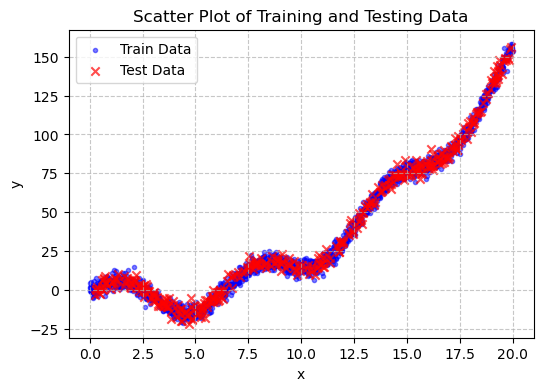

In [13]:
# Scatter Plot with 'x1' and 'y' columns ---

# Select the specified columns
x_train = train_data['x']
y_train = train_data['y']
x_test = test_data['x']
y_test = test_data['y']

# Create the scatter plot
plt.figure(figsize=(6, 4))

# Scatter plot for training data (blue circles)
plt.scatter(x_train, y_train, color='blue', label='Train Data', alpha=0.5, marker='.')

# Scatter plot for test data (red crosses)
plt.scatter(x_test, y_test, color='red', label='Test Data', alpha=0.7, marker='x')

# Add titles, labels, and legend
plt.title('Scatter Plot of Training and Testing Data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

### Analysis of Feature and Target Separation

- Input features and target variables are separated for both training and testing datasets.
- `X_train` and `X_test` contain predictor variables, while `y_train` and `y_test` contain the output values.
- Proper separation is a standard preprocessing step in supervised machine learning workflows.
- Keeping train and test data isolated prevents data leakage during model evaluation.
- This structure allows models to learn patterns from training data and generalize to unseen test data.


In [14]:
# Separate features and target variable in train data
X_train = train_data.drop(columns=['y'])
y_train = train_data['y']

# Separate features and target variable in test data
X_test = test_data.drop(columns=['y'])
y_test = test_data['y']

### Analysis of Optional Outlier Injection

- This section demonstrates how artificial outliers can be added into the training dataset.
- Outlier analysis is useful for understanding model robustness and sensitivity to abnormal observations.
- Extreme values can significantly influence regression models, especially linear methods.
- The code is intentionally commented to allow controlled experimentation only when needed.
- Comparing model performance before and after outlier injection helps evaluate algorithm stability.
- Robust algorithms generally show lower degradation in prediction accuracy when outliers are introduced.


In [15]:
# # Adding outliers (UNCOMMENT ONLY WHEN REQUIRED! SEE THE PROBLEM STATEMENTs ...)
# X_train = np.array(list(X_train['x1']) + [X_train['x1'].mean() + x for x in np.random.randn(5)]).reshape(-1,1)
# y_train = np.array(list(y_train) + [y_train.max() + 4 + x for x in np.random.randn(5)])

### Analysis of Polynomial Feature Generation

- Polynomial feature expansion is applied to transform the original feature space.
- Increasing the polynomial degree allows models to capture non linear relationships in the data.
- `fit_transform()` is applied on training data, while `transform()` is applied on test data to maintain consistency.
- Degree 1 currently preserves the original feature representation, but the structure supports future experimentation.
- Feature augmentation can improve model flexibility but may also increase the risk of overfitting.
- Polynomial transformations are commonly used in regression tasks when relationships are not strictly linear.


In [16]:
# Use PolynomialFeatures to create new features features
poly = PolynomialFeatures(degree=1)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

### Analysis of Feature Standardization

- Standardization scales features to have zero mean and unit variance.
- Scaling is especially important for algorithms sensitive to feature magnitude such as SVM and KNN.
- The scaler is fitted only on training data to avoid information leakage from the test set.
- Consistent scaling improves numerical stability and optimization efficiency.
- Standardized features allow fair comparison between variables measured on different scales.
- Preprocessing steps like normalization often improve convergence and model performance.


In [17]:
# standardization of the data
scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

### Analysis of Augmented Dataset Export

- The transformed dataset with engineered polynomial features is prepared for inspection and verification.
- Feature names are extracted to improve interpretability of the generated feature space.
- Saving processed datasets helps validate preprocessing operations before model training.
- Exporting augmented data is useful for debugging, reporting, and reproducibility purposes.
- Reviewing transformed features can reveal dimensionality growth caused by feature engineering.


In [18]:
####################################
# Save the augmented data set to a file for review

# Create dataframe with test data and additional features
# Get feature names
feature_names = poly.get_feature_names_out()
augmented_data = pd.DataFrame(X_train_poly, columns=feature_names)
augmented_data['y'] = train_data['y']

# # Write dataframe to CSV
augmented_data.to_csv('augmented_train_data.csv', index=False)
####################################
####################################
# Save the augmented data set to a file for review

# Create dataframe with test data and additional features
# Get feature names
feature_names = poly.get_feature_names_out()
augmented_data = pd.DataFrame(X_test_poly, columns=feature_names)
augmented_data['y'] = test_data['y']

# # Write dataframe to CSV
augmented_data.to_csv('augmented_test_data.csv', index=False)
####################################

### Analysis of Regression Algorithm Definition

- Multiple regression algorithms are initialized to compare predictive performance across methods.
- Linear Regression provides a baseline model for comparison.
- Support Vector Regression introduces non linear learning capability using kernel functions.
- Random Forest Regression captures complex relationships through ensemble tree learning.
- KNN Regression predicts outputs based on similarity between neighboring samples.
- Using multiple models enables comparative analysis of bias, variance, interpretability, and robustness.
- This setup supports systematic benchmarking of regression approaches on the same dataset.


In [19]:
# Algorithms
algorithms = {
    'Linear Regression': LinearRegression(),
    'SVM Regression': SVR(kernel='poly'),  # Adjust kernel as needed
    'RandomForest': RandomForestRegressor(),
    'XGBoost': GradientBoostingRegressor(),
    'knn': KNeighborsRegressor(),
    'Neural Network-10': MLPRegressor(hidden_layer_sizes=[10], max_iter=20000),
}

# Metric tables
metric_table_train = pd.DataFrame()
metric_table_test = pd.DataFrame()

### Analysis of Model Training, Prediction, and Visualization

- A subplot grid is created to compare outputs from all regression algorithms side by side.
- Each algorithm is trained using the transformed training dataset.
- Predictions are generated for both training and testing datasets.
- Evaluation metrics are computed to measure prediction accuracy and generalization performance.
- Visualization helps compare how closely predicted values align with actual observations.
- Plot based comparison allows detection of underfitting, overfitting, and prediction variance.
- Combining metrics with graphical analysis provides a more complete understanding of model behavior.


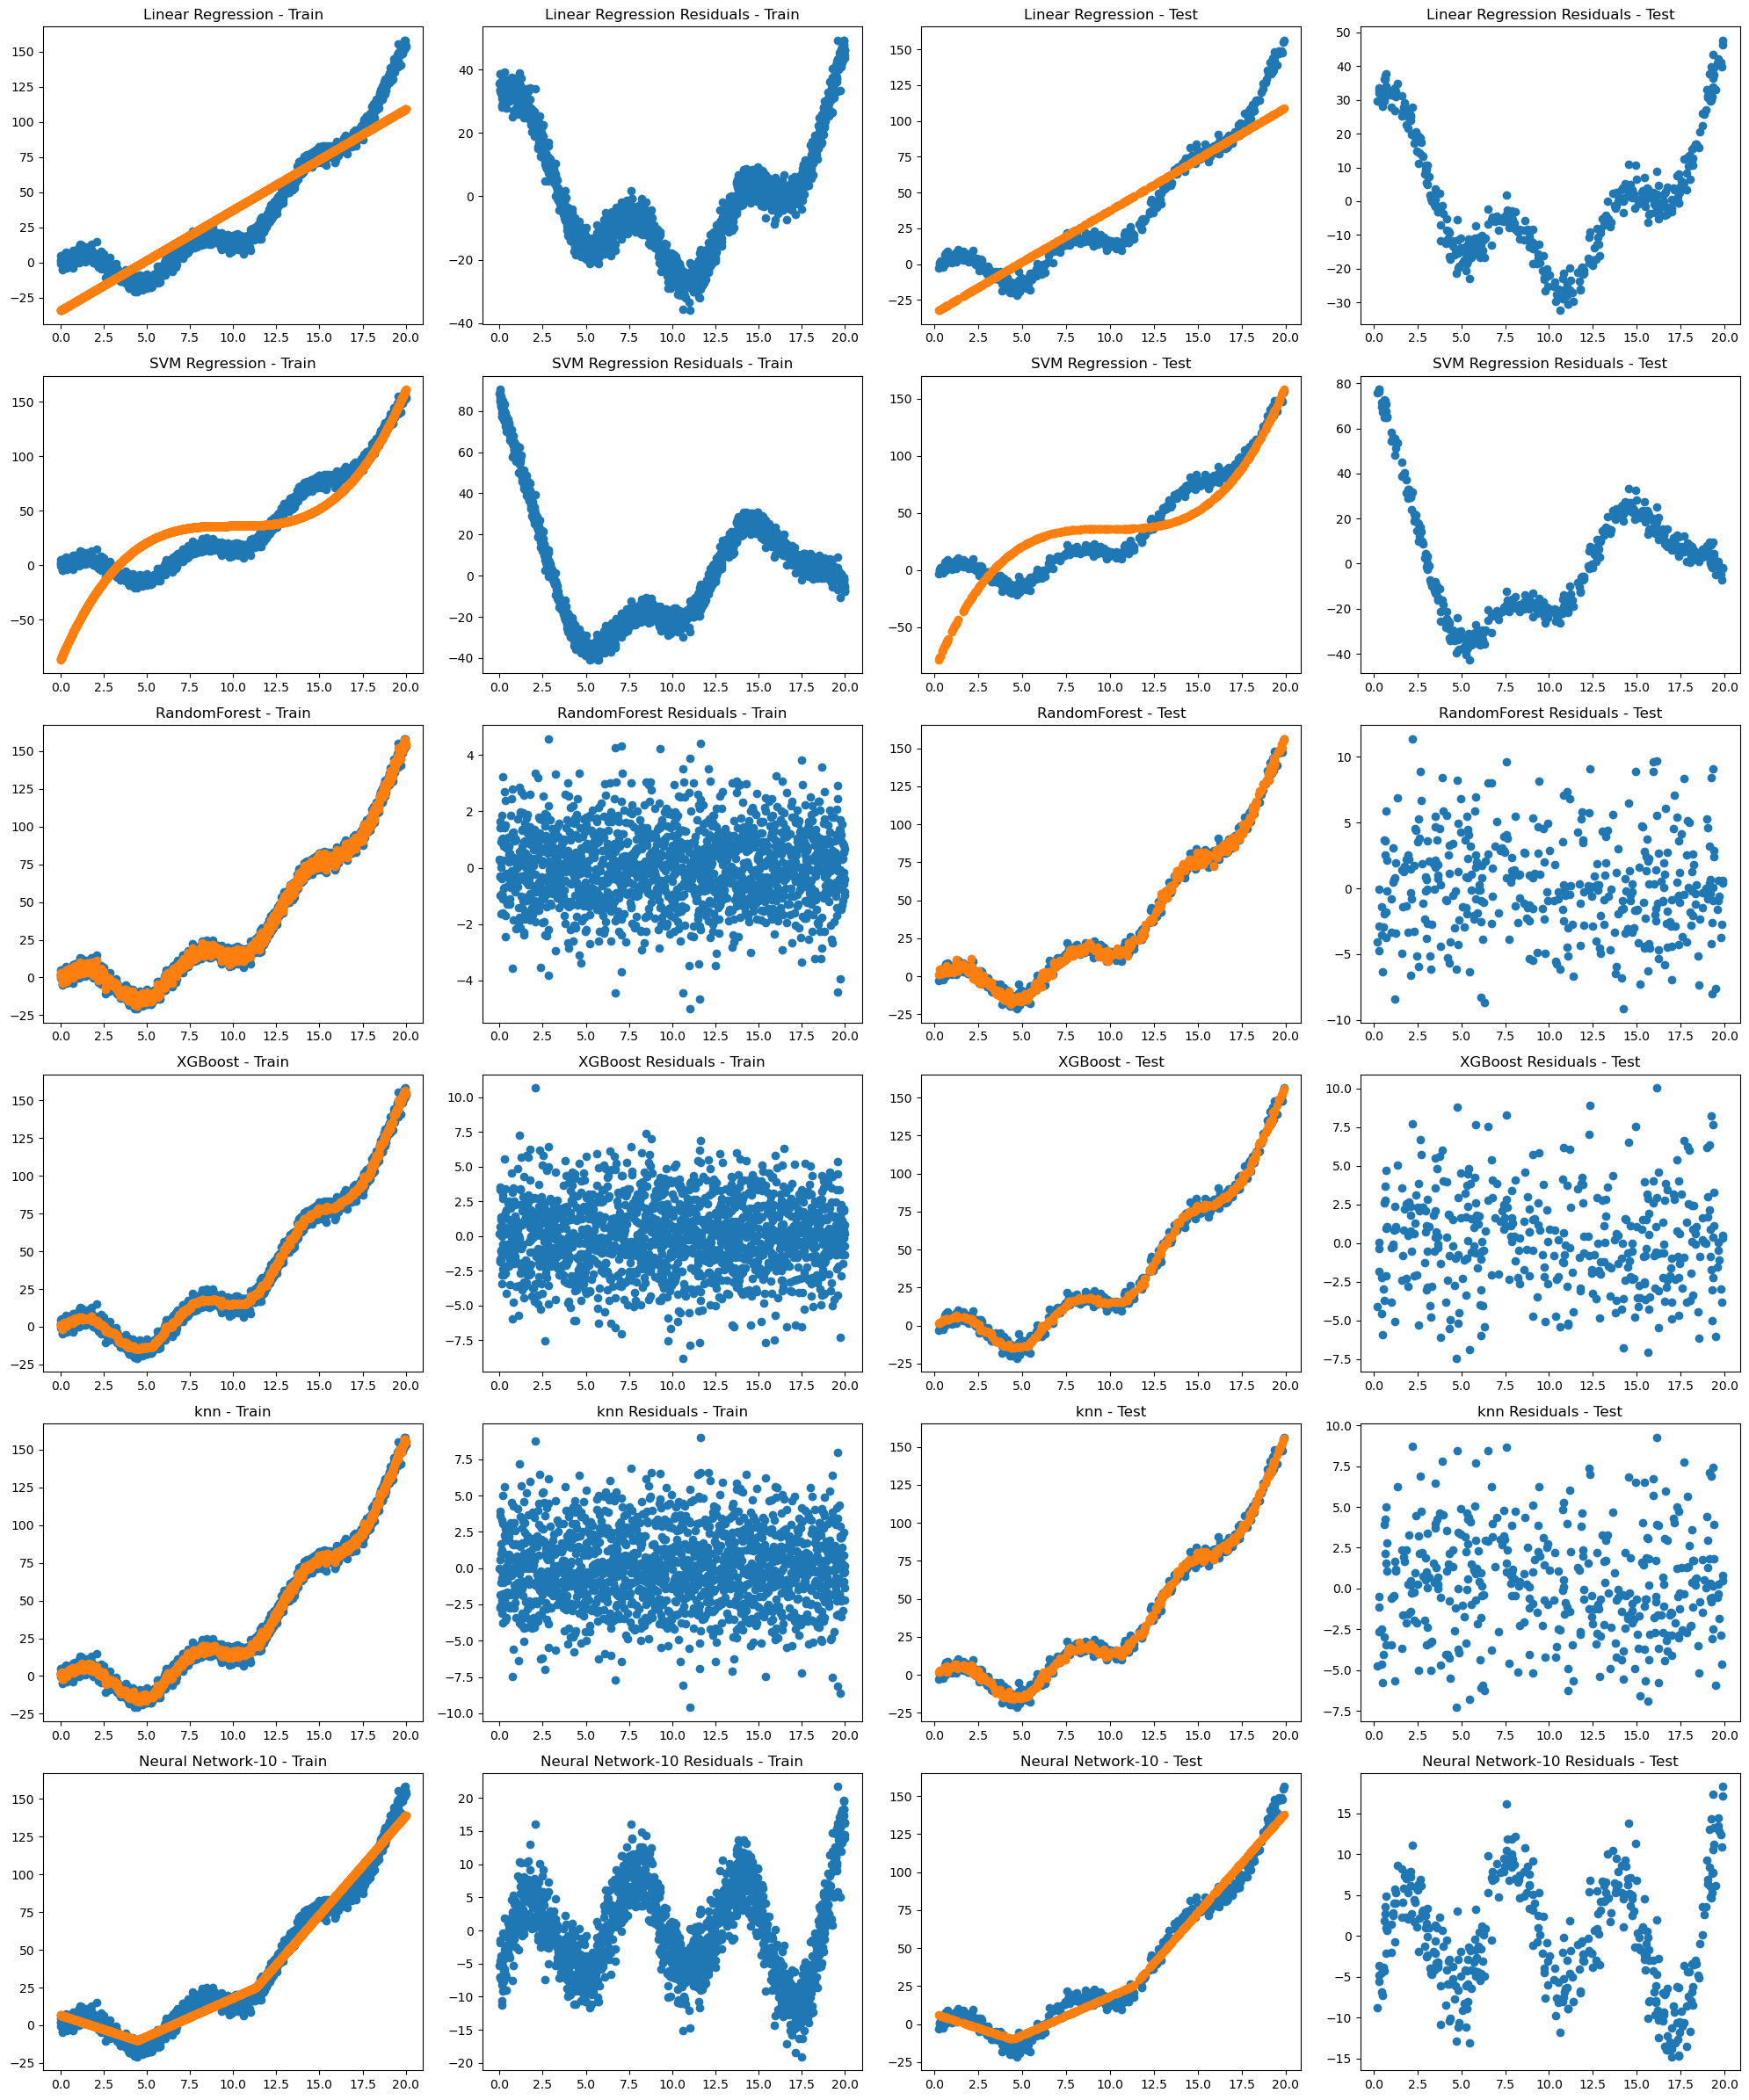

In [22]:
# Create a grid of subplots
fig, axs = plt.subplots(len(algorithms), 4, figsize=(20, 4 * len(algorithms)))
fig_row = -1

# Run the algorithms ... create metrics and plots
for algorithm_name, algorithm in algorithms.items():

    # Train model
    algorithm.fit(X_train_poly, y_train)

    # Train predictions
    y_train_pred = algorithm.predict(X_train_poly)

    # Test predictions
    y_test_pred = algorithm.predict(X_test_poly)

    # Train metrics
    r2_train = algorithm.score(X_train_poly, y_train)
    rmse_train = root_mean_squared_error(y_train, y_train_pred)

    # Test metrics
    r2_test = algorithm.score(X_test_poly, y_test)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)

    # Additional metrics using statsmodels for all algorithms
    residuals_train = y_train - y_train_pred
    residuals_test = y_test - y_test_pred

    durbin_watson_stat_train = sm.stats.durbin_watson(residuals_train)
    jb_stat_train, jb_p_value_train, _, _ = sm.stats.jarque_bera(residuals_train)

    durbin_watson_stat_test = sm.stats.durbin_watson(residuals_test)
    jb_stat_test, jb_p_value_test, _, _ = sm.stats.jarque_bera(residuals_test)

    # Update metric tables
    metric_table_train.at[algorithm_name, 'R-squared'] = r2_train
    metric_table_train.at[algorithm_name, 'RMSE'] = rmse_train
    metric_table_train.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_train
    metric_table_train.at[algorithm_name, 'Jarque-Bera'] = jb_stat_train
    metric_table_train.at[algorithm_name, 'JB P-value'] = jb_p_value_train

    metric_table_test.at[algorithm_name, 'R-squared'] = r2_test
    metric_table_test.at[algorithm_name, 'RMSE'] = rmse_test
    metric_table_test.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_test
    metric_table_test.at[algorithm_name, 'Jarque-Bera'] = jb_stat_test
    metric_table_test.at[algorithm_name, 'JB P-value'] = jb_p_value_test

    # Create the plots
    fig_row = fig_row+1

    axs[fig_row, 0].scatter(X_train, y_train)
    axs[fig_row, 0].scatter(X_train, y_train_pred)
    axs[fig_row, 0].set_title(algorithm_name + " - Train")

    axs[fig_row, 1].scatter(X_train, residuals_train)
    axs[fig_row, 1].set_title(algorithm_name + " Residuals - Train")

    axs[fig_row, 2].scatter(X_test, y_test)
    axs[fig_row, 2].scatter(X_test, y_test_pred)
    axs[fig_row, 2].set_title(algorithm_name + " - Test")

    axs[fig_row, 3].scatter(X_test, residuals_test)
    axs[fig_row, 3].set_title(algorithm_name + " Residuals - Test")
############################

plt.tight_layout()
plt.show()

### Analysis of Metrics Display

- Training and testing performance metrics are printed in tabular form.
- Comparing train and test metrics helps evaluate model generalization.
- Large differences between training and testing accuracy may indicate overfitting.
- Metrics such as MAE, RMSE, and R² provide complementary perspectives on prediction quality.
- Structured metric tables improve readability and simplify comparison across algorithms.
- Quantitative evaluation is essential for selecting the most suitable regression model.


In [23]:
# Display the metrics' Tables
print("Metrics - Train Data:\n")
print(metric_table_train.to_string())
print("-------------------------------------------------")

print("Metrics - Test Data:\n")
print(metric_table_test.to_string())

Metrics - Train Data:

                   R-squared       RMSE  Durbin-Watson  Jarque-Bera    JB P-value
Linear Regression   0.829553  18.656644       2.024608   117.827752  2.594351e-26
SVM Regression      0.638358  27.175561       1.987561   251.590113  2.332926e-55
RandomForest        0.999132   1.331492       2.053460     9.115382  1.048624e-02
XGBoost             0.996693   2.598827       2.089983     0.569595  7.521666e-01
knn                 0.996597   2.636220       2.092280     0.573307  7.507718e-01
Neural Network-10   0.977496   6.779078       2.042096    16.589599  2.498126e-04
-------------------------------------------------
Metrics - Test Data:

                   R-squared       RMSE  Durbin-Watson  Jarque-Bera    JB P-value
Linear Regression   0.850458  18.078457       1.904427    25.441873  2.987910e-06
SVM Regression      0.689803  26.037513       1.990964    35.111435  2.374919e-08
RandomForest        0.993391   3.800531       2.086859     3.053705  2.172183e-01
XGB

### Residual Analysis Plots

### Analysis of Residual Error Visualization

- Residual analysis is performed to evaluate prediction errors for each regression model.
- Residuals represent the difference between actual and predicted values.
- Well distributed residuals around zero usually indicate a better fitting model.
- Patterns in residual plots may reveal non linearity, heteroscedasticity, or systematic prediction bias.
- Comparing residual behavior across algorithms helps assess model reliability.
- Residual diagnostics are an important part of regression validation and interpretability.


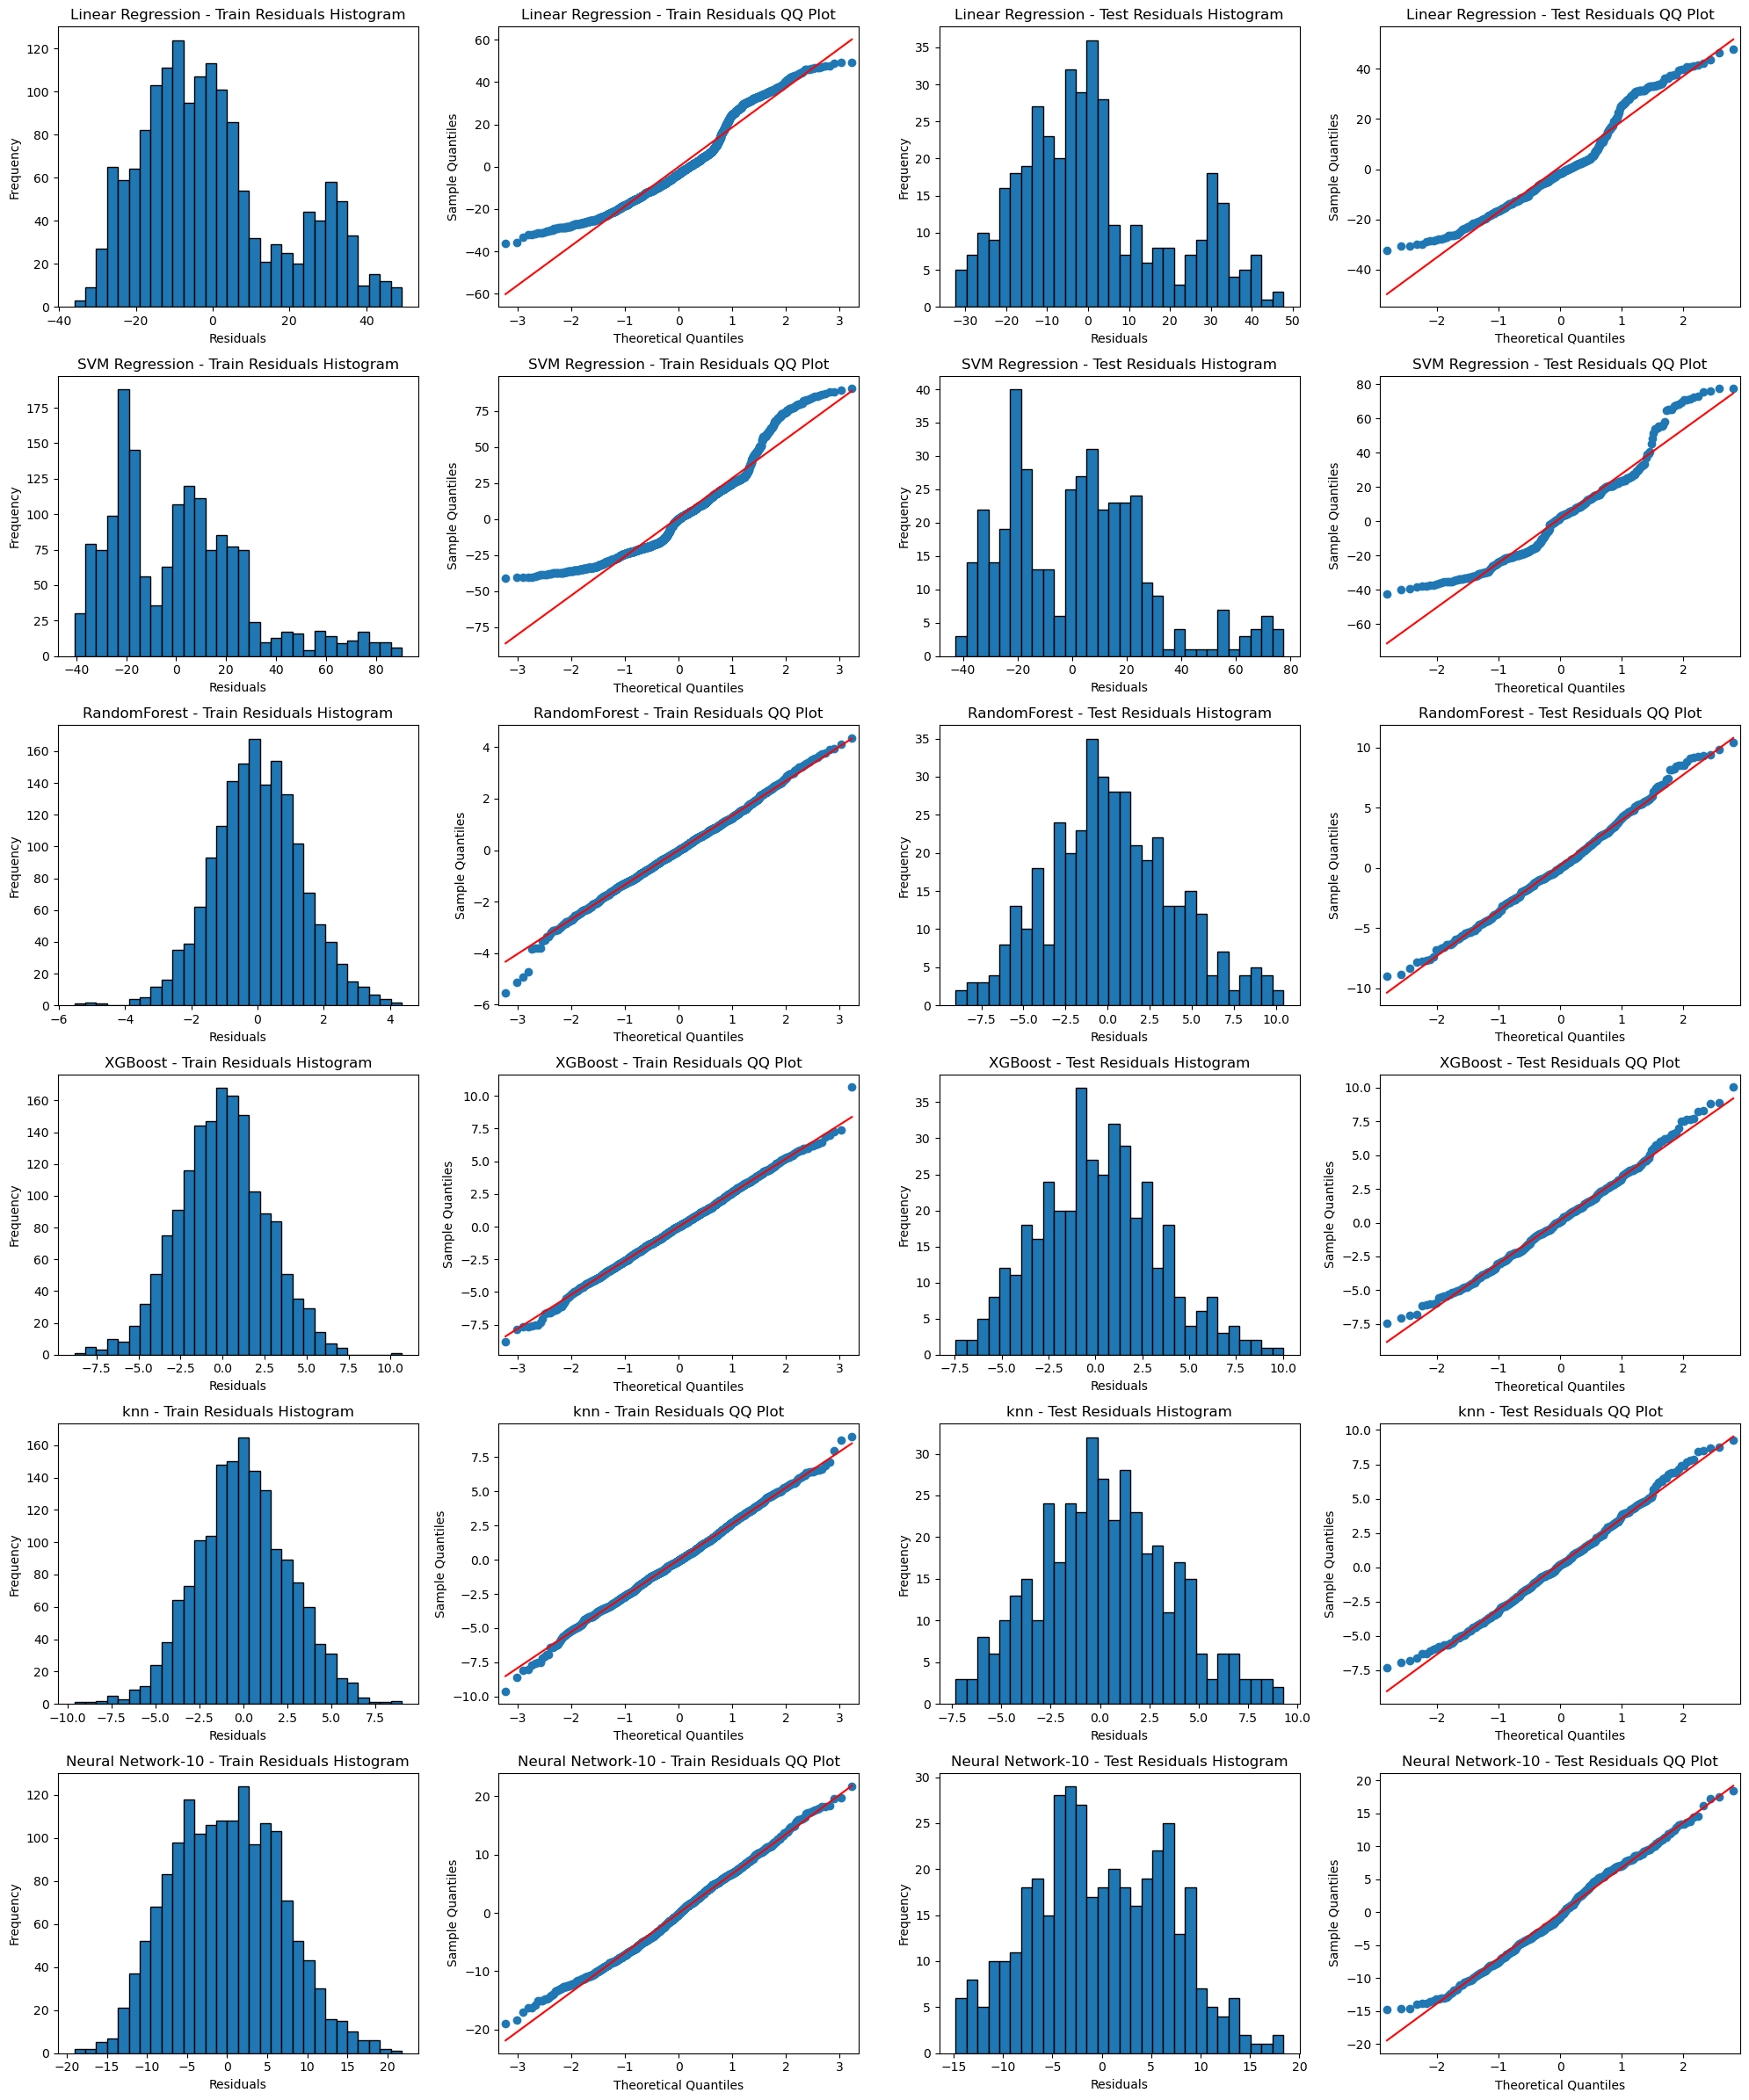

In [24]:
# Create a grid of subplots for residual analysis
fig_residuals, axs_residuals = plt.subplots(len(algorithms), 4, figsize=(20, 4 * len(algorithms)))
fig_row_residuals = -1

for algorithm_name, algorithm in algorithms.items():

    # Train model (re-train to ensure access to predictions if not already available in this scope)
    # These predictions are already available from the previous cell's execution,
    # but re-running fit and predict here ensures the current cell is self-contained
    # if run independently.
    algorithm.fit(X_train_poly, y_train)
    y_train_pred = algorithm.predict(X_train_poly)
    y_test_pred = algorithm.predict(X_test_poly)

    residuals_train = y_train - y_train_pred
    residuals_test = y_test - y_test_pred

    fig_row_residuals = fig_row_residuals + 1

    # Training Residuals: Histogram
    axs_residuals[fig_row_residuals, 0].hist(residuals_train, bins=30, edgecolor='black')
    axs_residuals[fig_row_residuals, 0].set_title(f'{algorithm_name} - Train Residuals Histogram')
    axs_residuals[fig_row_residuals, 0].set_xlabel('Residuals')
    axs_residuals[fig_row_residuals, 0].set_ylabel('Frequency')

    # Training Residuals: QQ Plot
    sm.qqplot(residuals_train, line='s', ax=axs_residuals[fig_row_residuals, 1])
    axs_residuals[fig_row_residuals, 1].set_title(f'{algorithm_name} - Train Residuals QQ Plot')

    # Test Residuals: Histogram
    axs_residuals[fig_row_residuals, 2].hist(residuals_test, bins=30, edgecolor='black')
    axs_residuals[fig_row_residuals, 2].set_title(f'{algorithm_name} - Test Residuals Histogram')
    axs_residuals[fig_row_residuals, 2].set_xlabel('Residuals')
    axs_residuals[fig_row_residuals, 2].set_ylabel('Frequency')

    # Test Residuals: QQ Plot
    sm.qqplot(residuals_test, line='s', ax=axs_residuals[fig_row_residuals, 3])
    axs_residuals[fig_row_residuals, 3].set_title(f'{algorithm_name} - Test Residuals QQ Plot')

plt.tight_layout()
plt.show();

# Assignment 9

### Algorithm comparison: observations from Assignment 9

Assignment 9 ran 15 model configurations on a 5-class 2D dataset. Rather than re-running all of them, let's read the results table from the solution and extract the key conceptual lessons from each algorithm family.

### The results table (from A9 solution markdown)

| Algorithm | Train Acc | Test Acc | Gap | Train AUC | Test AUC |
|---|---|---|---|---|---|
| Logistic Regression | 90.75% | **87.33%** | 3.4pp | 0.9903 | **0.9888** |
| LR (polynomial, deg=2) | 90.33% | **87.33%** | 3.0pp | 0.9901 | 0.9886 |
| SVC (linear) | 90.75% | 87.00% | 3.8pp | 0.9905 | 0.9883 |
| SVC (RBF) | 91.00% | 87.00% | 4.0pp | 0.9901 | 0.9871 |
| RF (leaf=1, depth=5) | 92.83% | 86.33% | 6.5pp | 0.9948 | 0.9845 |
| RF (leaf=3, depth=5) | 92.50% | 86.67% | 5.8pp | 0.9944 | 0.9848 |
| RF (leaf=5, depth=2) | 85.67% | 84.00% | 1.7pp | 0.9818 | 0.9760 |
| RF (leaf=5, depth=4) | 91.67% | **87.33%** | 4.3pp | 0.9916 | 0.9841 |
| KNN (k=3) | 91.33% | 84.33% | 7.0pp | 0.9951 | 0.9439 |
| KNN (k=5) | 91.58% | 84.00% | 7.6pp | 0.9945 | 0.9559 |
| KNN (k=7) | 90.83% | 84.33% | 6.5pp | 0.9938 | 0.9692 |
| NN (4 units) | 84.17% | 83.00% | 1.2pp | 0.9704 | 0.9692 |
| NN (4,4) | 64.17% | 69.67% | **−5.5pp** | 0.9199 | 0.9249 |
| NN (4,4,4) | 77.25% | 78.00% | **−0.75pp** | 0.9571 | 0.9444 |
| NN (8 units) | 85.75% | 84.67% | 1.1pp | 0.9815 | 0.9795 |

*Gap = Train Acc − Test Acc. Negative = test accuracy is higher than training accuracy.*

---

### 💬 Discussion — one observation per algorithm family

**Logistic Regression — linear was enough.**  
Plain LR and polynomial LR both achieved *exactly* 87.33% test accuracy. Adding degree-2 polynomial features gave zero benefit. This tells you something about the data's geometry: the five clusters are approximately linearly separable. The extra curved boundaries the polynomial version can draw weren't needed. Lesson: start with the simplest model and only add complexity if the simple one is insufficient.

**SVC — kernel choice didn't matter here.**  
Linear and RBF kernels both landed at 87.0%. The RBF kernel can draw complex non-linear boundaries, but it found no advantage over the linear one. Again, the data geometry is forgiving. SVC's big selling point over logistic regression is the margin — it explicitly maximises the distance between the decision boundary and the nearest training points, which can improve robustness.

**Random Forest — the clearest bias-variance demonstration in the assignment.**  
- `depth=2`: both train and test accuracy are low (85.67% / 84.00%), small gap. This is **underfitting** — the shallow tree can only make 2 binary splits, drawing very coarse rectangular boundaries.
- `leaf=1, depth=5`: highest train accuracy (92.83%) but *lower* test accuracy (86.33%) than RF4. Large gap. This is **overfitting** — it grows deep branches to explain even noisy training points.
- `leaf=5, depth=4`: ties for best test accuracy with a moderate gap. The sweet spot.

**KNN — the AUC collapse.**  
KNN (k=3) had one of the highest *train* AUC values (0.9951) but the worst *test* AUC (0.9439) — a 5.1pp collapse. Compare that to accuracy: train 91.33%, test 84.33%, a 7pp gap. The accuracy gap is bad but not dramatic. The AUC gap is the real story: KNN's probability estimates (based on counting 3 neighbours) are very sensitive to local noise and don't transfer to new data. As k increases, the boundary smooths and AUC recovers (k=7 reaches 0.9692). KNN is accurate enough at classifying, but poorly calibrated in its confidence.

**Neural Networks — the negative gap.**  
NN (4,4) had train accuracy of 64.17% and test accuracy of 69.67% — test *higher* than train. This looks like phenomenal generalisation, but it's actually a **red flag**. It means the optimiser got stuck in a poor local minimum during training. Neural network training uses gradient descent on a non-convex loss surface — it is not guaranteed to find the global optimum. The model essentially failed to learn the training data well. NN (8 units) — wider, shallower — avoided this problem and scored 84.67% test accuracy, confirming that width mattered more than depth for this problem.

--

### 💬 Final discussion questions

1. **LR vs polynomial LR both gave 87.33%.** If you were presenting these results, which would you recommend deploying, and why? *(Think: model complexity, interpretability, what happens if a new data point is very far from the training distribution.)*

2. **KNN's AUC collapsed more than its accuracy.** Why is this gap between accuracy and AUC informative? In what real-world application would you care more about AUC than accuracy?

3. **NN (4,4) had test accuracy > train accuracy.** A student might report this as "the model generalises well — it does better on unseen data!" How would you explain why this reasoning is wrong?

4. **Class 3 was the hardest across all models.** Without looking at the scatter plot, what would you infer about Class 3's position in the 2D feature space? What would you try next to improve its F1 specifically?

5. **RF (depth=2) had a 1.7pp train-test gap — the smallest of all RF variants.** Does a small train-test gap mean it's the best model? What is the full picture needed to judge a model?

# Assignment 10 & 11

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("healthcare_dataset_missing.csv")

print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)

df.head()

Shape of dataset: (55500, 15)

Columns:
 Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='str')


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30.0,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62.0,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,NaN,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76.0,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28.0,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43.0,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


### Q1 Carry out the following data understanding and integrity checks
- a. How many rows and columns are present in the data?
- b. How many rows and how many columns have missing data?


In [27]:
rows, cols = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

Number of rows: 55500
Number of columns: 15



Missing values per column:
 Age                  5550
Medical Condition      56
Billing Amount       2775
dtype: int64

Total rows with at least one missing value: 8077


C:\Users\MAYANK\AppData\Local\Temp\ipykernel_11744\1425617947.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_col.index, y=missing_col.values, palette='viridis')


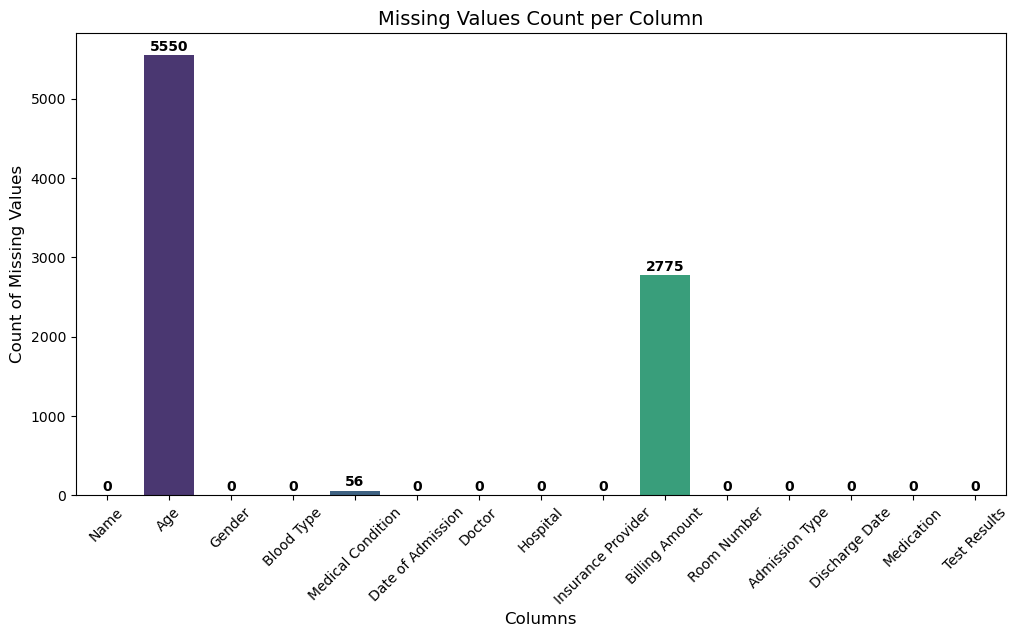

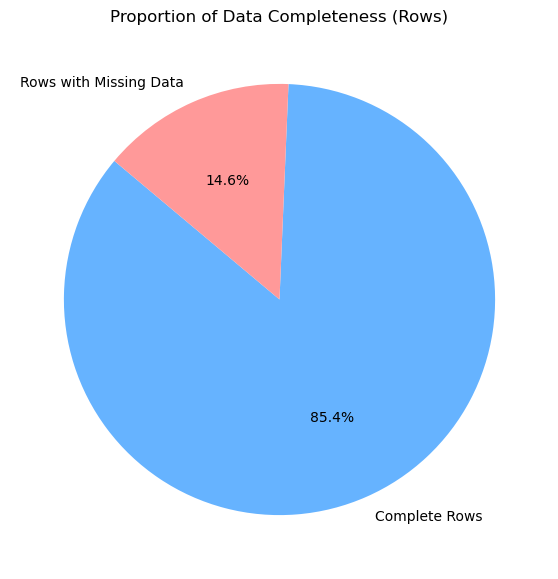

In [28]:
missing_col = df.isnull().sum()
rows_with_missing = df.isnull().any(axis=1).sum()

cols_with_missing = missing_col[missing_col > 0]
print("\nMissing values per column:\n", cols_with_missing)
print(f"\nTotal rows with at least one missing value: {rows_with_missing}")

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_col.index, y=missing_col.values, palette='viridis')
plt.title('Missing Values Count per Column', fontsize=14)
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Count of Missing Values', fontsize=12)
plt.xticks(rotation=45)


for i, v in enumerate(missing_col.values):
    plt.text(i, v + (max(missing_col.values)*0.01), str(v), ha='center', fontweight='bold')
plt.show()


plt.figure(figsize=(7, 7))
plt.pie([rows - rows_with_missing, rows_with_missing],
        labels=['Complete Rows', 'Rows with Missing Data'],
        autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.title('Proportion of Data Completeness (Rows)')
plt.show()

<Axes: >

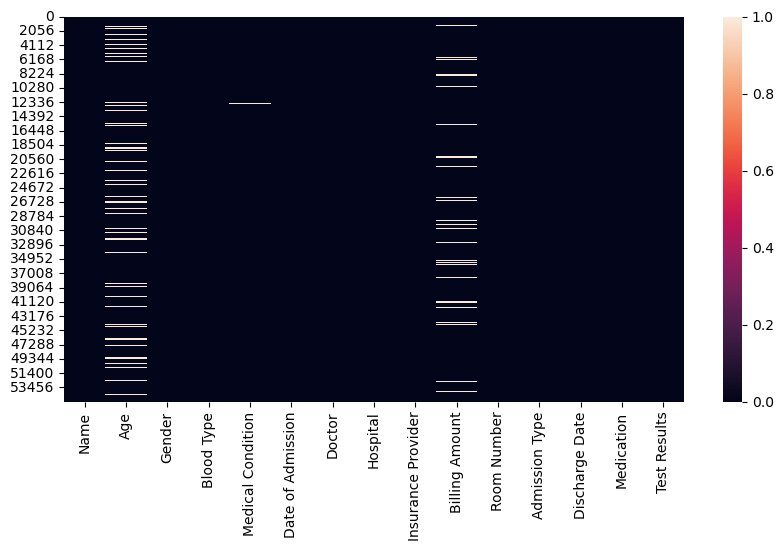

In [29]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull())

### Q2 Identify the level of measurement associated with each column

##### Importance of level of measurement.
- The choice between Regression and Classification depends entirely on the Level of Measurement of the Target Variable (the column you are trying to predict)
- 1. Regression: Used when the target variable is Ratio or Interval (Numerical/Continuous).
     Since these variables represent quantities, we want to predict a specific numeric value.
- 2. Classification: Used when the target variable is Nominal or Ordinal (Categorical/Discrete). Since these variables represent labels or categories,       we want to predict which "bucket" an observation falls into.

In [30]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [31]:
def detect_measurement(col):
    if pd.api.types.is_numeric_dtype(col):
        return "Ratio"
    elif pd.api.types.is_datetime64_any_dtype(col):
        return "Interval (Time)"
    else:
        return "Nominal"

measurement = {col: detect_measurement(df[col]) for col in df.columns}

for col, m in measurement.items():
    print(f"{col}: {m}")

Name: Nominal
Age: Ratio
Gender: Nominal
Blood Type: Nominal
Medical Condition: Nominal
Date of Admission: Interval (Time)
Doctor: Nominal
Hospital: Nominal
Insurance Provider: Nominal
Billing Amount: Ratio
Room Number: Ratio
Admission Type: Nominal
Discharge Date: Interval (Time)
Medication: Nominal
Test Results: Nominal


### Q3 Create appropriate Descriptive Statistics information for every column, based on it’s level of
### measurement, and organize all this data in Tables for easy analysis and decision making.
 - a. Analyze the descriptive statistics thus generated and make your initial conclusions

In [32]:
print("\nNumerical Summary:\n")
print(df.describe())


Numerical Summary:

                Age           Date of Admission  Billing Amount   Room Number  \
count  49950.000000                       55500    52725.000000  55500.000000   
mean      51.516957  2021-11-01 01:02:22.443243    25543.061974    301.134829   
min       13.000000         2019-05-08 00:00:00    -2008.492140    101.000000   
25%       35.000000         2020-07-28 00:00:00    13235.899822    202.000000   
50%       52.000000         2021-11-01 00:00:00    25537.614046    302.000000   
75%       68.000000         2023-02-03 00:00:00    37850.378393    401.000000   
max       89.000000         2024-05-07 00:00:00    52764.276736    500.000000   
std       19.611681                         NaN    14219.073455    115.243069   

                   Discharge Date  
count                       55500  
mean   2021-11-16 13:15:20.821621  
min           2019-05-09 00:00:00  
25%           2020-08-12 00:00:00  
50%           2021-11-17 00:00:00  
75%           2023-02-18 00:00:00

In [33]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Name ---
Name
DAvId muNoZ       3
adrIENNE bEll     2
pAUL wILLiAmS     2
Nancy glOVeR      2
JONathAn yaTeS    2
                 ..
CaRl CHaNDlEr     1
JOSepH PaUl       1
braDleY dAniEL    1
LiSa sIMPsoN      1
RoGER farRELl     1
Name: count, Length: 49992, dtype: int64

--- Gender ---
Gender
Male      27774
Female    27726
Name: count, dtype: int64

--- Blood Type ---
Blood Type
A-     6969
A+     6956
AB+    6947
AB-    6945
B+     6945
B-     6944
O+     6917
O-     6877
Name: count, dtype: int64

--- Medical Condition ---
Medical Condition
Arthritis       9305
Diabetes        9292
Hypertension    9236
Obesity         9222
Cancer          9213
Asthma          9176
Name: count, dtype: int64

--- Doctor ---
Doctor
Michael Smith      27
John Smith         22
Robert Smith       22
James Smith        20
Michael Johnson    20
                   ..
Cody Smith          1
Shannon Morales     1
Arthur Fleming      1
Deborah Sutton      1
Mary Bartlett       1
Name: count, Length: 403

C:\Users\MAYANK\AppData\Local\Temp\ipykernel_11744\3811726862.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


C:\Users\MAYANK\AppData\Local\Temp\ipykernel_11744\2030216248.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', ax=axes[1,0], palette='pastel')
C:\Users\MAYANK\AppData\Local\Temp\ipykernel_11744\2030216248.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Blood Type', ax=axes[1,1], palette='Set2')
C:\Users\MAYANK\AppData\Local\Temp\ipykernel_11744\2030216248.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Medical Condition', ax=axes[2,0], palette='viridis')
C:\Users\MAYANK\AppData

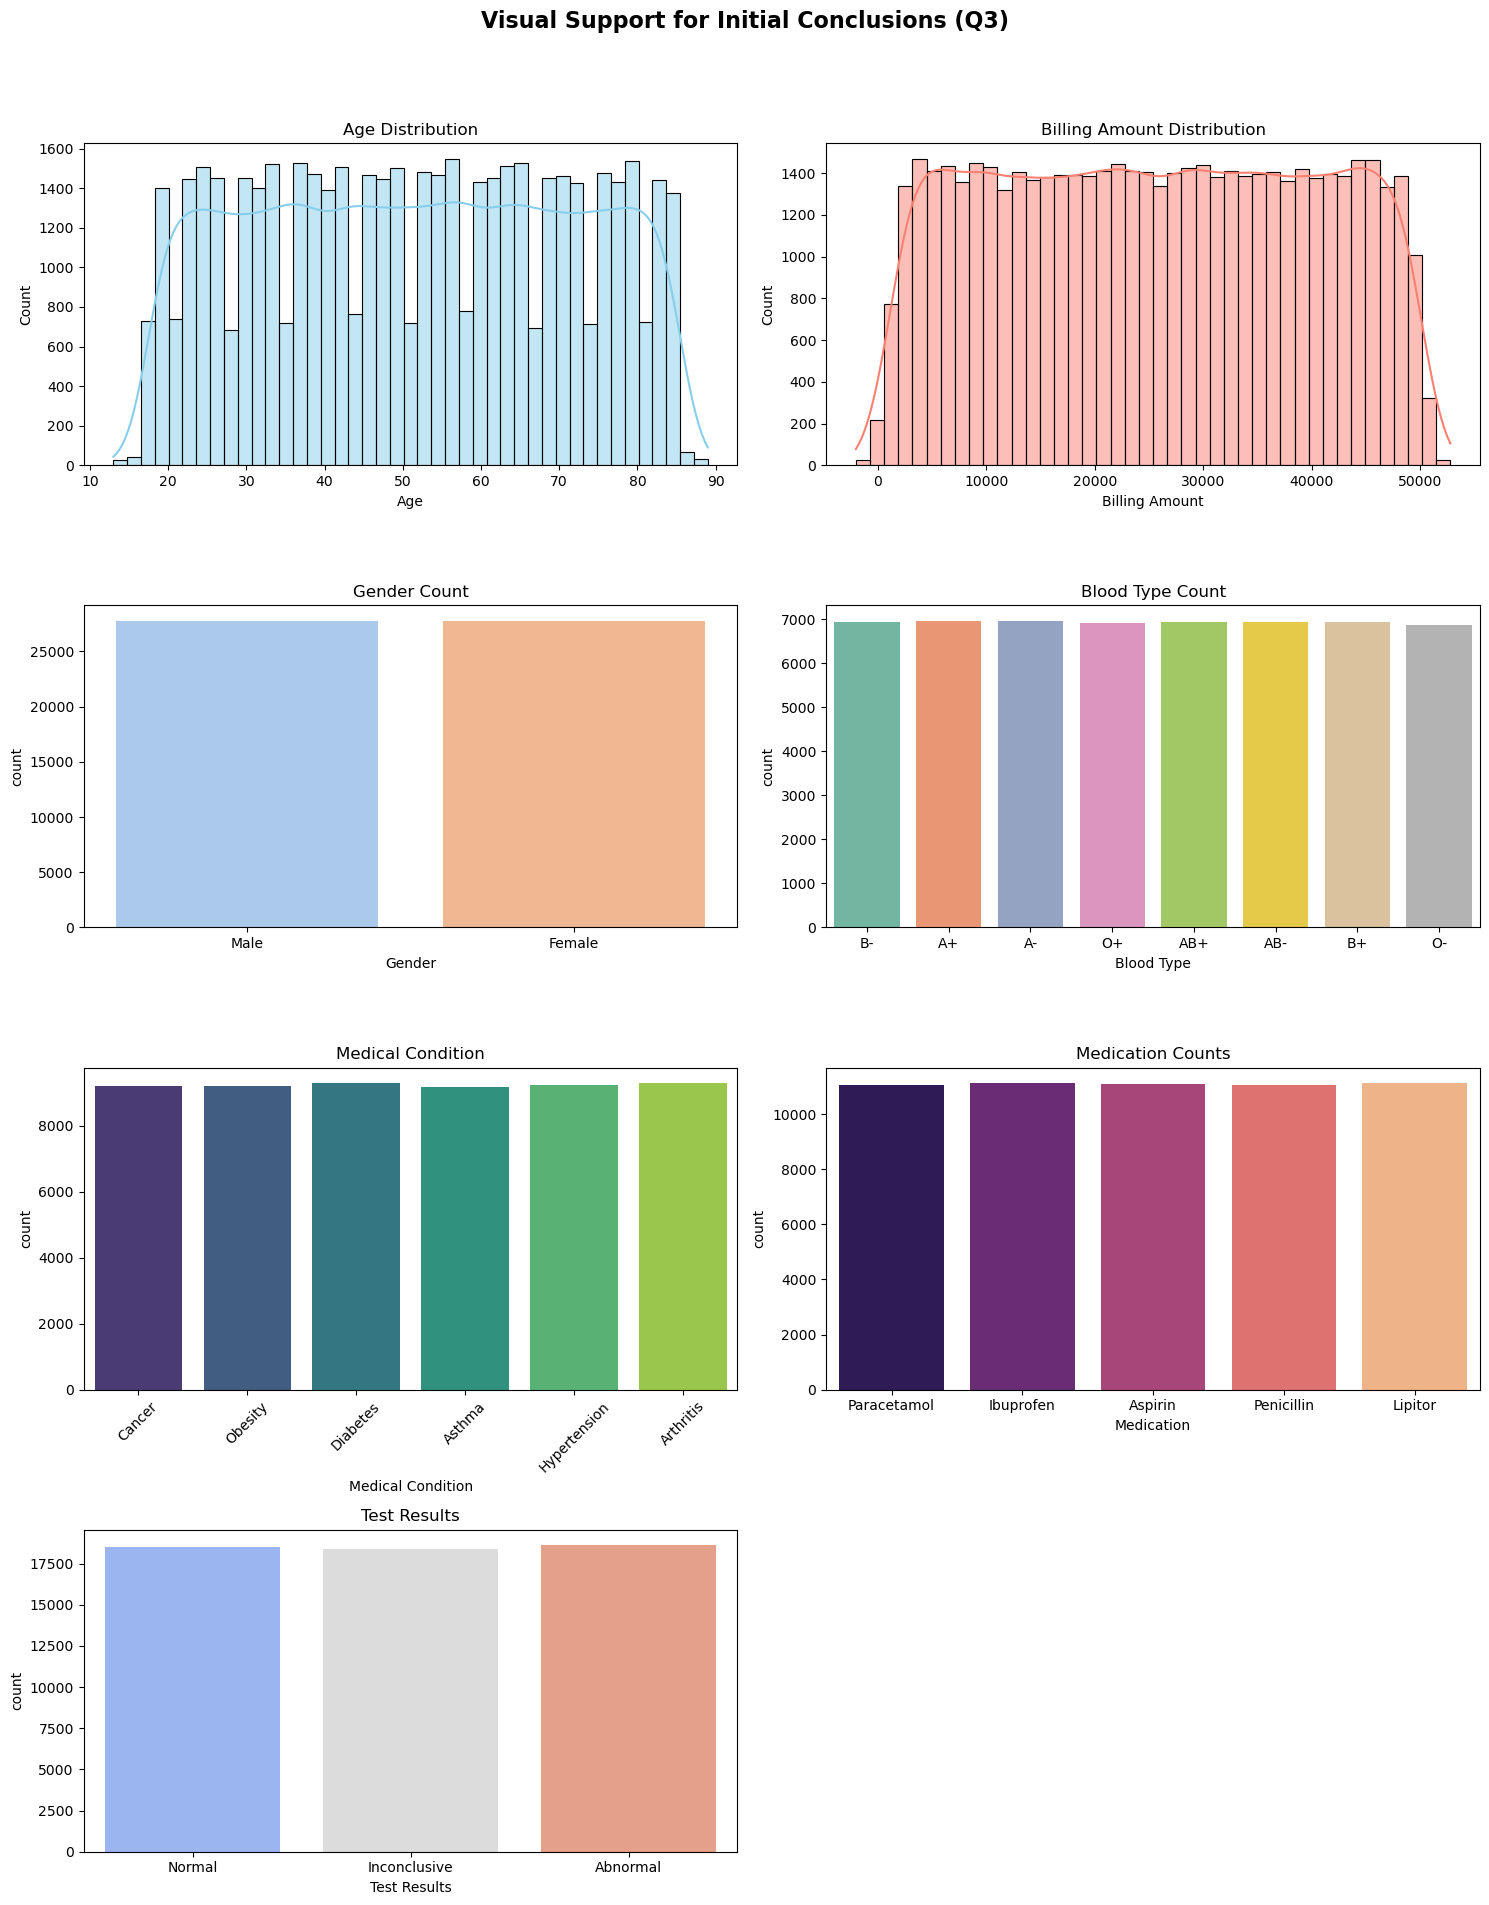

In [34]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
fig.suptitle('Visual Support for Initial Conclusions (Q3)', fontsize=16, fontweight='bold')

# 1. Age Distribution
sns.histplot(df['Age'], kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Age Distribution')

# 2. Billing Amount
sns.histplot(df['Billing Amount'], kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Billing Amount Distribution')

# 3. Gender
sns.countplot(data=df, x='Gender', ax=axes[1,0], palette='pastel')
axes[1,0].set_title('Gender Count')

# 4. Blood Type
sns.countplot(data=df, x='Blood Type', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Blood Type Count')

# 5. Medical Condition
sns.countplot(data=df, x='Medical Condition', ax=axes[2,0], palette='viridis')
axes[2,0].tick_params(axis='x', rotation=45)
axes[2,0].set_title('Medical Condition')

# 6. Medication
sns.countplot(data=df, x='Medication', ax=axes[2,1], palette='magma')
axes[2,1].set_title('Medication Counts')

# 7. Test Results
sns.countplot(data=df, x='Test Results', ax=axes[3,0], palette='coolwarm')
axes[3,0].set_title('Test Results')

# Hide the empty 8th subplot
axes[3,1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\MAYANK\AppData\Local\Temp\ipykernel_11744\921685992.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Age Group', y='Billing Amount', data=df, palette='coolwarm')


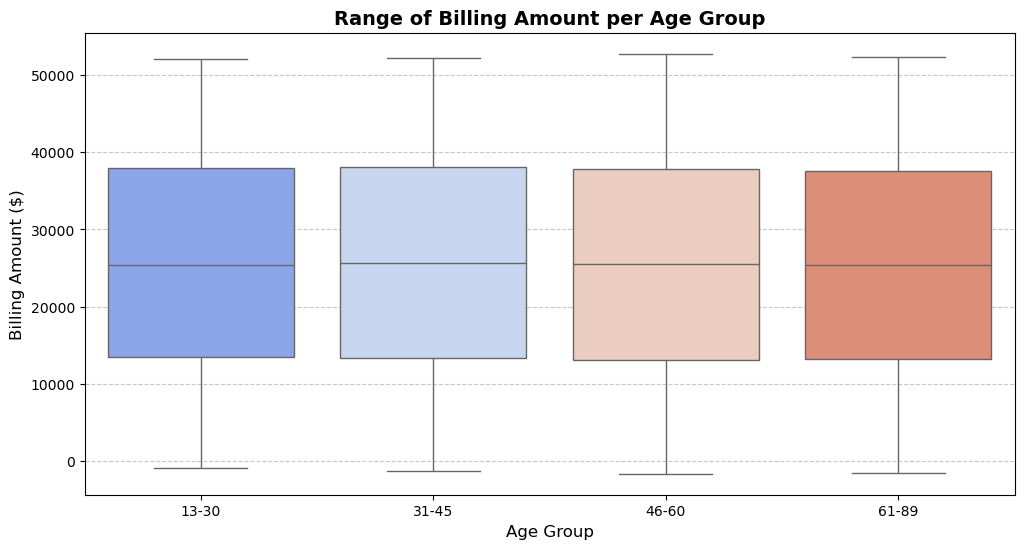

In [35]:
age_bins = [13, 30, 45, 60, 89]
age_labels = ['13-30', '31-45', '46-60', '61-89']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, include_lowest=True)

# 2. Box Plot: Range of Billing Amount by Age Group
plt.figure(figsize=(12, 6))
sns.boxplot(x='Age Group', y='Billing Amount', data=df, palette='coolwarm')
plt.title('Range of Billing Amount per Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Billing Amount ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Age
- The histogram and KDE show a Uniform Distribution rather than a Normal one
- The lack of a 'bell curve' suggests that this hospital doesn't specialize in age-specific care
- The mean and median are likely very close (around 51-52), confirming the symmetry

### Billing Amount
- The distribution is remarkably flat (uniform) between 0 and 50,000.
- The presence of values at or below zero (visible at the far left of the X-axis) strongly suggests data entry errors, refunds, or unbilled cases that    require cleaning.
- The box plot for billing amount vs age group suggests that Age has zero impact on Billing Amount. In this dataset, being a senior (61–85) doesn't       make you any more likely to have a high bill than being a young adult (18–30).

### Gender
- No gender bias
- The count plot shows a near 50/50 split, indicating the dataset is perfectly balanced for gender-based studies.

### Blood Type
- Uniform Distribution
- No dominance of any group

### Medical Condition
- Very well balanced
- Likely synthetic dataset
- There is no 'dominant' disease or 'preferred' drug.


### Medication
- Almost equal counts


### Test Results
- No Class imbalance

### Q6 Analyze the Age column with the help of appropriate visualizations. What can you conclude? Are there any missing values in this column? How will you handle them? Why?

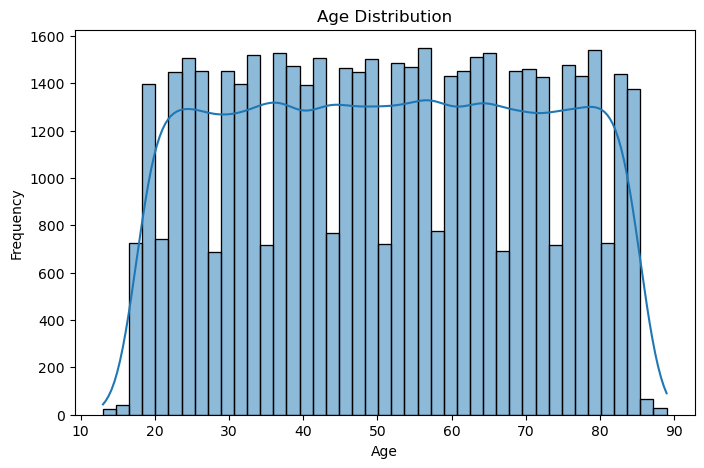

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

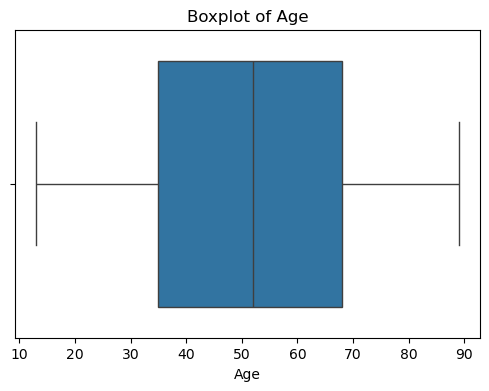

In [37]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Age")
plt.show()

- #### Fill missing Age using patients with the SAME condition
- #### Median imputation grouped by Medical Condition is preferred because age distributions vary across different diseases.
- #### Using a global median ignores these differences and may introduce bias.
- #### Group-wise median imputation preserves the relationship between Age and Medical Condition, leading to more realistic and reliable data representation.
- #### Additionally, median is robust to outliers, making it a better choice than mean.

### Q7 Create histograms and KDE plots (find out what KDE plots represent) for all the columns and analyze them. Any significant conclusions?

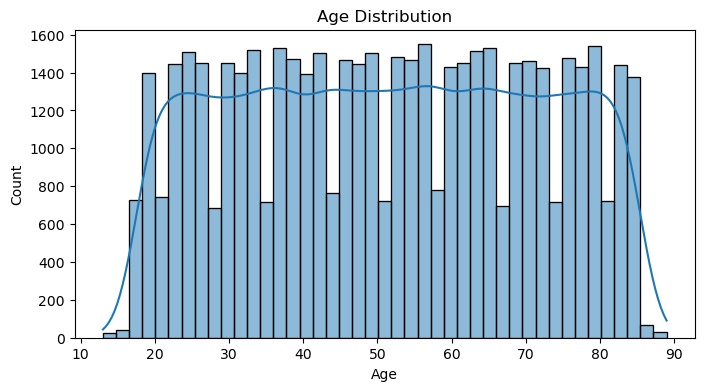

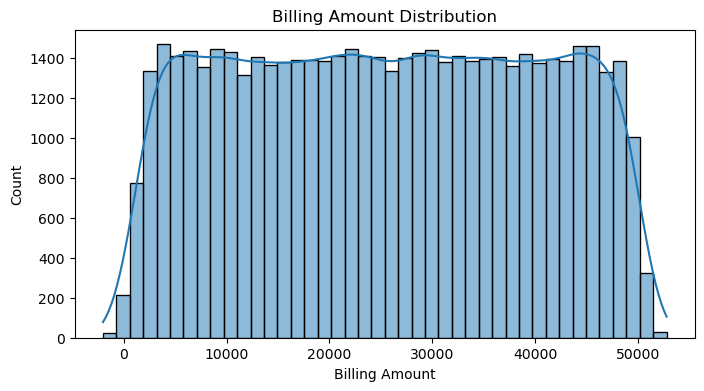

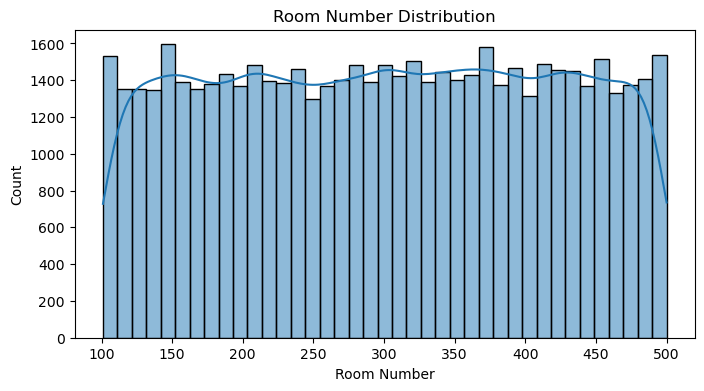

In [38]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

### Age
- Histogram is fairly flat
- KDE curve is almost uniform
- Range: ~18 to 85
- No skewness, no clustering

### Billing Amount
- Values spread from ~0 to ~52,000
- KDE is also flat
- Slight irregularities due to noise
- Some values near 0 and below → possible anomalies

### Room Number
- Not meaningful for analysis or prediction

### Q8 Create box plots for all the columns, individually, and analyze them. What are your conclusions?

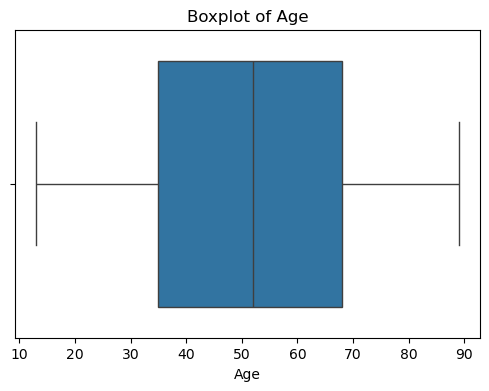

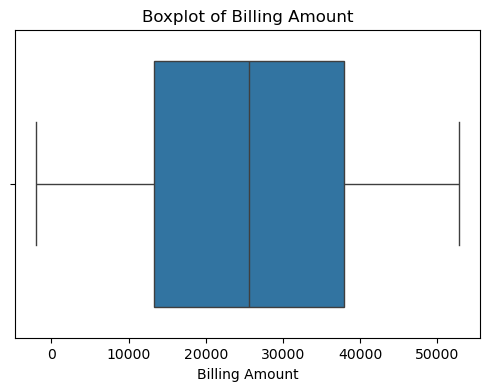

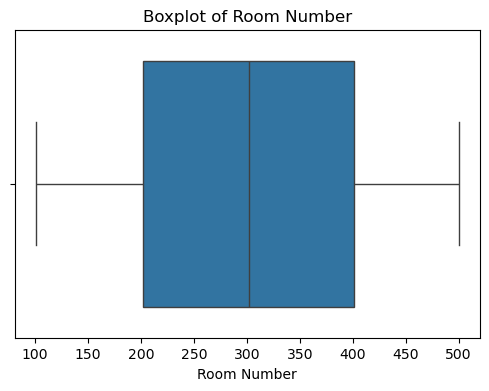

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Age
- No visible outliers
- Median ≈ 52
- Symmetric
- IQR ≈ 35 to 68

### Billing Amount
- Median ≈ 25,500
- No strong outliers
- IQR ≈ 13,000 to 38,000

### Room Number
- Median ≈ 300
- IQR ≈ 200 to 400
- No outliers

### Q9 Create box plots for all the numerical columns on a common scale, and in a single plot, and analyze this plot. What do you observe? What are its implications?

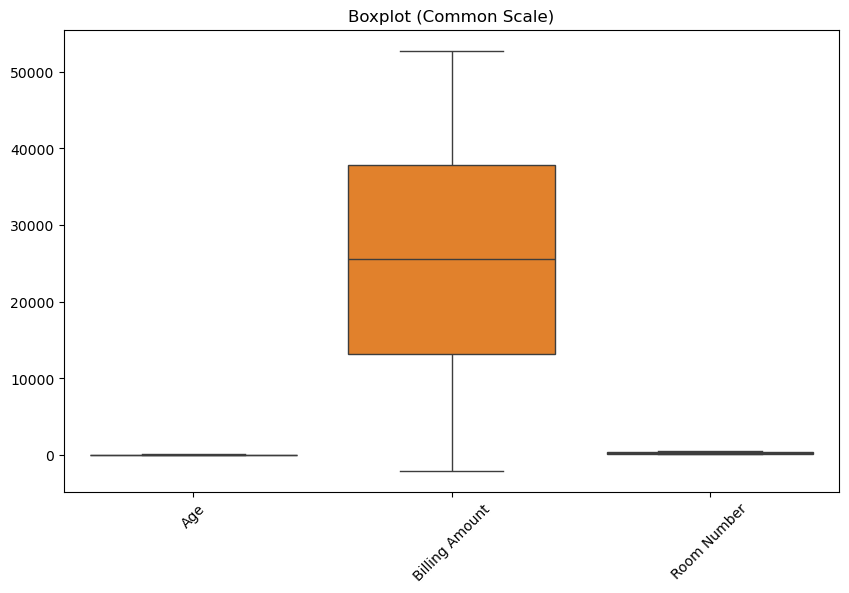

In [40]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[numerical_cols])
plt.title("Boxplot (Common Scale)")
plt.xticks(rotation=45)
plt.show()

- Billing Amount dominates the scale
- Age and Room Number are compressed near zero
- Cant compare distributions properly
- Feature Scaling is necessary
- Without scaling models will be biased

### Q11 Based on all the analysis so far, what is your final conclusion regarding the handling of missing values? Implement your decision!

In [41]:
df['Medical Condition'].fillna("Unknown", inplace=True)

df['Age'] = df.groupby('Medical Condition')['Age'].transform(lambda x: x.fillna(x.median()))

df.loc[df['Billing Amount'] < 0, 'Billing Amount'] = np.nan
df['Billing Amount'] = df.groupby('Medical Condition')['Billing Amount'].transform(lambda x: x.fillna(x.median()))


C:\Users\MAYANK\AppData\Local\Temp\ipykernel_11744\2779968673.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Medical Condition'].fillna("Unknown", inplace=True)


#### Medical Condition
- Medical Condition is a Nominal (categorical) variable.
- If you fill missing values with the most common disease, you artificially inflate that category. This creates "bias" and might lead a model to think that this category is more prevalent than it actually is.
- By creating a new category called "Unknown," you preserve the data without making assumptions.

#### Age
- Medical data is often "domain-dependent." For example, the typical age of a patient with "Arthritis" might be 65, while "Diabetes" might span all ages.
- This method preserves the correlation between the condition and the age, making your synthetic data more realistic for the model.
- The Median is robust to outliers. If your dataset had a few 120-year-olds (data errors), the mean would be pulled higher, but the median stays stable.

#### Billing Amount
- Treat the negative values as NaN, as they are data entry errors.
- By imputing the median cost for that specific condition, you ensure that your "filled-in" values reflect the likely economic reality of that patient's situation.

In [42]:
print(df.isnull().sum())

Name                     0
Age                     56
Gender                   0
Blood Type               0
Medical Condition       56
Date of Admission        0
Doctor                   0
Hospital                 0
Insurance Provider       0
Billing Amount          56
Room Number              0
Admission Type           0
Discharge Date           0
Medication               0
Test Results             0
Age Group             5550
dtype: int64


# Assignment 12

## Superconductivity Dataset — ML, Dimensionality Reduction, Clustering & Regression

| | |
|---|---|
| **Dataset** | Superconductor Dataset (Hamidieh, 2018) |
| **Samples** | 10,000 |
| **Features** | 81 numerical features + 1 target (`critical_temp`) |
| **Task** | Part A: Visualization, Feature Engineering, Clustering  ·  Part B: Regression Modelling |

> Each row represents a superconducting material. The 81 features are statistical aggregates
> (mean, weighted mean, geometric mean, entropy, range, std) of 9 elemental properties.
> The target `critical_temp` is the temperature in Kelvin below which the material exhibits
> zero electrical resistance.


## Library Imports


In [43]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
FIGSIZE = (14, 5)

from sklearn.preprocessing   import StandardScaler, FunctionTransformer
from sklearn.impute          import SimpleImputer
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.base            import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.decomposition   import PCA
from sklearn.manifold        import TSNE
from sklearn.cluster         import KMeans, AgglomerativeClustering
from sklearn.metrics         import silhouette_score, davies_bouldin_score
from sklearn.linear_model    import LinearRegression, Ridge, Lasso
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import (RandomForestRegressor, ExtraTreesRegressor,
                                       GradientBoostingRegressor)
from sklearn.metrics         import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.cluster.hierarchy import dendrogram, linkage

print('All libraries loaded successfully!')


All libraries loaded successfully!


---
## PART A — Visualization, Feature Engineering & Clustering
### Section 1: Dataset Loading and EDA


### Q1. Dataset Loading and Initial Diagnostics

**Objective:** Load the Superconductor Dataset, inspect its structure and quality,
separate features and target, and understand the 9×9 feature engineering structure.


In [44]:
# ── Load dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv('Superconductor_Dataset_10000.csv')

# ── Display first 5 rows ──────────────────────────────────────────────────────
print('First 5 rows:')
print(df.head())

# ── Basic diagnostics ─────────────────────────────────────────────────────────
print('\n' + '='*60)
print('  DATASET OVERVIEW')
print('='*60)
print(f'  Rows           : {df.shape[0]:,}')
print(f'  Columns        : {df.shape[1]}')
print(f'  Features (X)   : {df.shape[1] - 1}  (all numerical)')
print(f'  Target (y)     : critical_temp')
print(f'  Duplicates     : {df.duplicated().sum()}')
print(f'  Missing values : {df.isnull().sum().sum()}')

# ── Numerical vs Categorical ───────────────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).shape[1]
cat_cols = df.select_dtypes(exclude=[np.number]).shape[1]
print(f'  Numerical cols : {num_cols}')
print(f'  Categorical cols: {cat_cols}')
print('='*60)

# ── Feature/target split ──────────────────────────────────────────────────────
X = df.iloc[:, :-1]          # All 81 feature columns
y = df['critical_temp']      # Target: critical temperature in Kelvin

print(f'\nFeature matrix X : {X.shape}')
print(f'Target vector  y : {y.shape}')
print(f'\nTarget statistics:')
print(y.describe().to_string())

# ── Feature group breakdown ───────────────────────────────────────────────────
print('\nFeature group breakdown (9x9 structure):')
elemental_props = ['atomic_mass','fie','atomic_radius','Density',
                   'ElectronAffinity','FusionHeat','ThermalConductivity','Valence']
for prop in elemental_props:
    cols = [c for c in X.columns if prop in c]
    print(f'  {prop:<30} -> {len(cols)} features')
print(f'  number_of_elements             -> 1 feature')
print(f'\nTotal features: {X.shape[1]}')


First 5 rows:
   number_of_elements  mean_atomic_mass  wtd_mean_atomic_mass  \
0                   4         88.944468             57.862692   
1                   5         92.729214             58.518416   
2                   4         88.944468             57.885242   
3                   4         88.944468             57.873967   
4                   4         88.944468             57.840143   

   gmean_atomic_mass  wtd_gmean_atomic_mass  entropy_atomic_mass  \
0          66.361592              36.116612             1.181795   
1          73.132787              36.396602             1.449309   
2          66.361592              36.122509             1.181795   
3          66.361592              36.119560             1.181795   
4          66.361592              36.110716             1.181795   

   wtd_entropy_atomic_mass  range_atomic_mass  wtd_range_atomic_mass  \
0                 1.062396          122.90607              31.794921   
1                 1.057755          122.90

#### 📝 Analysis — Q1: Dataset Loading and Initial Diagnostics

**Q1a. Is this a regression or classification problem? Justify using the target variable type.**
> **Answer:** This is a **regression** problem. The target variable `critical_temp` is a
> **continuous physical quantity** measured in Kelvin, ranging from 0.00 K to 143.00 K.
> Since the output is a real-valued number (not a discrete category), we must predict it
> with a regression model. Classification would require arbitrarily discretising Tc into
> temperature bins, which would lose ordinal information and introduce artificial boundaries
> that have no physical meaning.

**Q1b. What is the 9×9 structure of features? Why does it create multicollinearity?**
> **Answer:** The 81 features follow a structured **9 elemental properties × 9 statistical
> descriptors = 81 features** pattern.
> - **9 elemental properties:** atomic mass, atomic radius, valence, electron affinity,
>   ionization energy (fie), thermal conductivity, density, fusion heat, number of elements.
> - **9 statistical descriptors per property:** mean, weighted mean, geometric mean,
>   weighted geometric mean, entropy, weighted entropy, range, weighted range, std/weighted std.
>
> **Multicollinearity arises** because multiple descriptors of the same property are
> mathematically related — e.g., `mean_atomic_mass` and `wtd_mean_atomic_mass` differ only
> in weighting scheme, so they carry largely redundant information. Result: **67 feature pairs**
> have |Pearson r| ≥ 0.90.

**Q1c. Are there any data quality issues that must be addressed before modelling?**
> **Answer:**
> - **Missing values: 0** — no imputation required at this stage.
> - **Duplicate rows: 1** (0.01% of data) — negligible; can be dropped as a precaution.
> - **All 82 columns are numerical** — no encoding needed.
> - **Main concern:** extreme multicollinearity from the 9×9 structure → addressed by VIF
>   elimination in Q4.

**Q1d. What is the range of the target variable `critical_temp`?**
> **Answer:**
> - **Range:** 0.00 K to 143.00 K
> - **Mean:** 58.62 K | **Median:** 62.00 K | **Std:** ~31 K
> - 0 K → materials with no measurable superconductivity
> - 143 K → high-Tc cuprate superconductors (e.g., HgBa₂Ca₂Cu₃O₈)
> - High std (~31 K) indicates large variability across different material families.


### Q2. Exploratory Data Analysis (EDA)

**Objective:** Understand the statistical properties, distributions, correlations,
and relationships in the dataset before modelling.


In [45]:
# ── Statistical summary ───────────────────────────────────────────────────────
print('Statistical summary of all features:')
stats_summary = X.describe().T
stats_summary['skewness'] = X.skew().round(3)
print(stats_summary[['mean','std','min','50%','max','skewness']].head(20).to_string())
print(f'\n... ({X.shape[1]} features total)')
high_skew = (X.skew().abs() > 1).sum()
print(f'\nFeatures with |skewness| > 1: {high_skew} / {X.shape[1]}')


Statistical summary of all features:
                               mean         std         min          50%          max  skewness
number_of_elements         5.093100    0.926671    2.000000     5.000000     9.000000     0.342
mean_atomic_mass          85.572585   14.868362   16.335723    86.270733   149.050333    -0.381
wtd_mean_atomic_mass      61.185413   15.890144   12.219975    56.687867   152.464120     1.257
gmean_atomic_mass         64.716410   10.975350   12.157891    65.092472   145.690031    -0.870
wtd_gmean_atomic_mass     41.861040   14.421462    6.881007    35.997493   137.387467     1.735
entropy_atomic_mass        1.398570    0.193143    0.240242     1.435319     1.938709    -0.614
wtd_entropy_atomic_mass    1.336368    0.210275    0.040647     1.343788     1.958203    -0.443
range_atomic_mass        146.822378   33.937025   10.979069   128.242600   207.972460     0.042
wtd_range_atomic_mass     24.103361   11.518585    1.565455    20.940758   137.643230     1.299
std

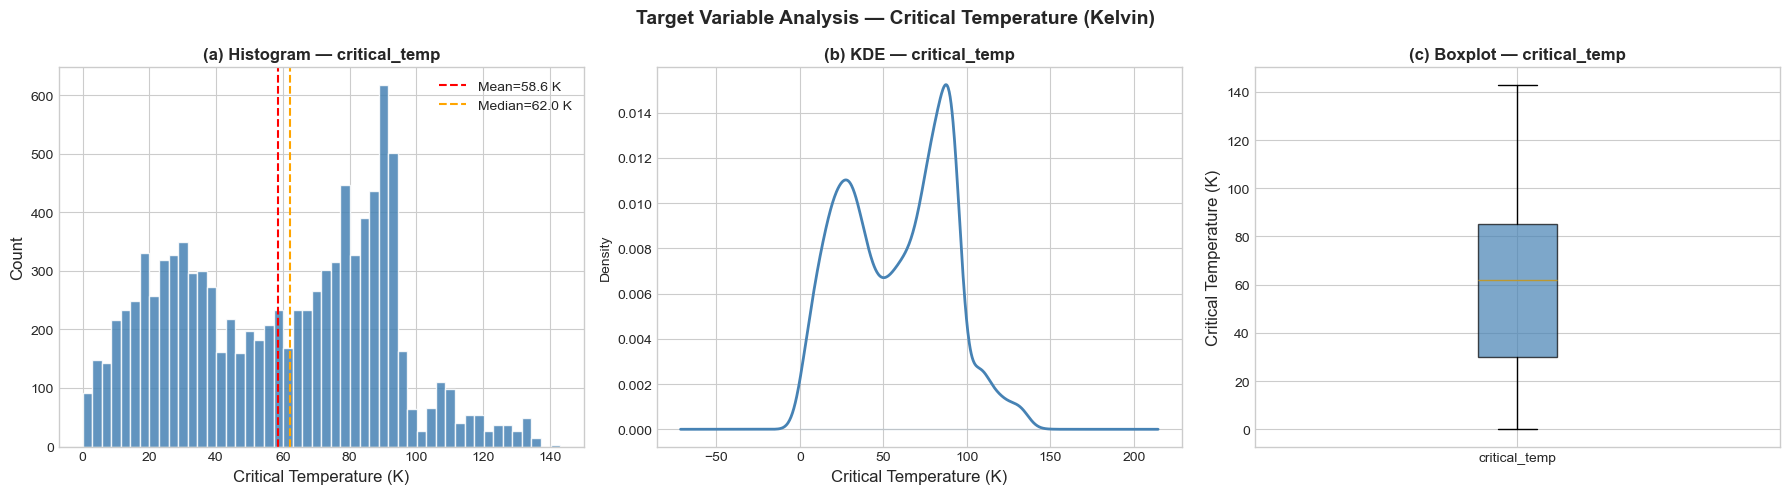

In [46]:
# ── Target variable analysis: 3-panel figure ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Histogram with mean and median lines
axes[0].hist(y, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(y.mean(),   color='red',    linestyle='--', label=f'Mean={y.mean():.1f} K')
axes[0].axvline(y.median(), color='orange', linestyle='--', label=f'Median={y.median():.1f} K')
axes[0].set_xlabel('Critical Temperature (K)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('(a) Histogram — critical_temp', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# (b) KDE plot
y.plot.kde(ax=axes[1], color='steelblue', linewidth=2)
axes[1].fill_between(np.linspace(y.min(), y.max(), 200), [0]*200, color='steelblue', alpha=0.1)
axes[1].set_xlabel('Critical Temperature (K)', fontsize=12)
axes[1].set_title('(b) KDE — critical_temp', fontsize=12, fontweight='bold')

# (c) Boxplot
axes[2].boxplot(y, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[2].set_ylabel('Critical Temperature (K)', fontsize=12)
axes[2].set_title('(c) Boxplot — critical_temp', fontsize=12, fontweight='bold')
axes[2].set_xticks([1]); axes[2].set_xticklabels(['critical_temp'])

plt.suptitle('Target Variable Analysis — Critical Temperature (Kelvin)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


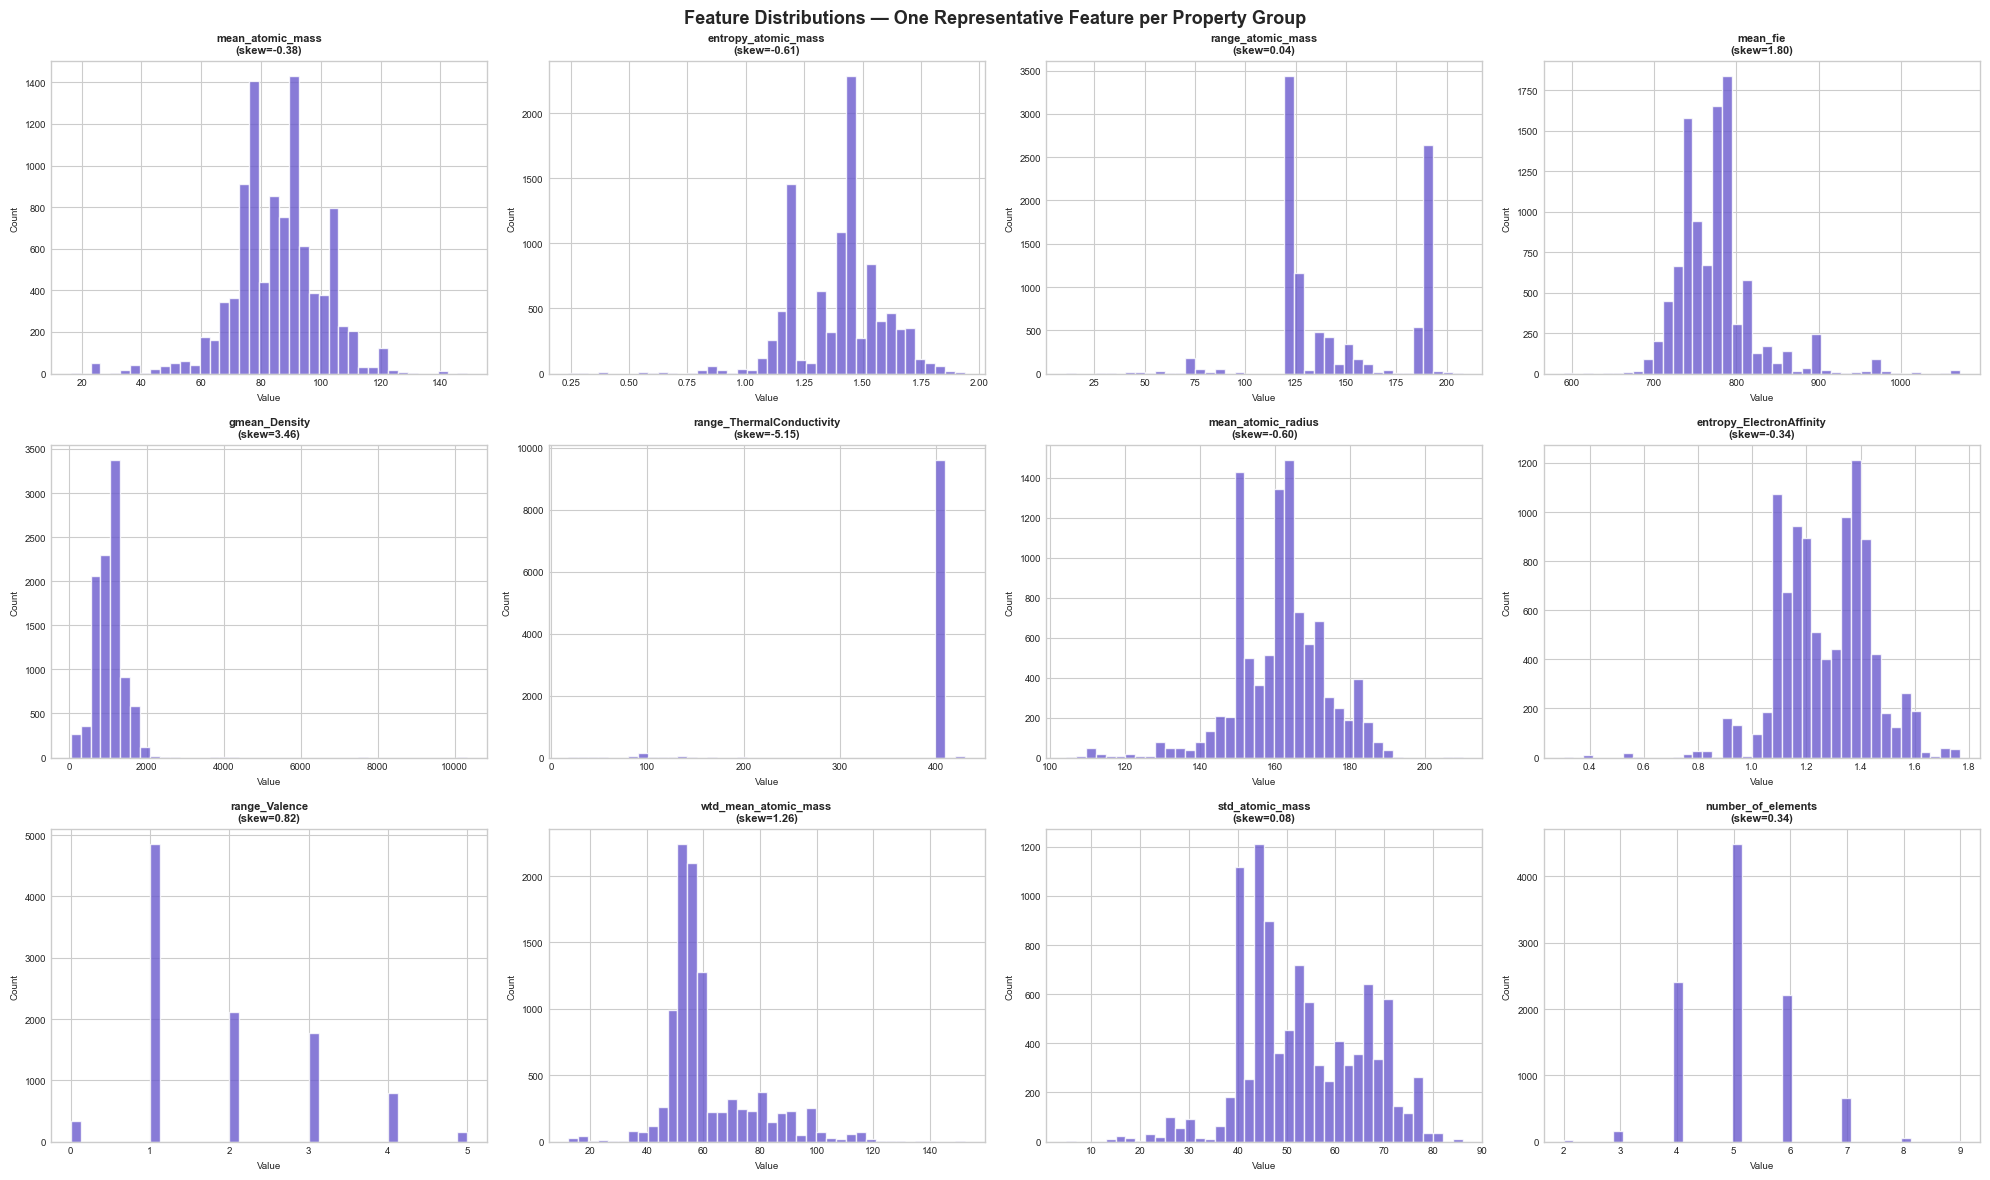

In [47]:
# ── Feature distributions: 12 representative features ───────────────────────
sample_features = [
    'mean_atomic_mass', 'entropy_atomic_mass', 'range_atomic_mass',
    'mean_fie', 'gmean_Density', 'range_ThermalConductivity',
    'mean_atomic_radius', 'entropy_ElectronAffinity', 'range_Valence',
    'wtd_mean_atomic_mass', 'std_atomic_mass', 'number_of_elements'
]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
for i, feat in enumerate(sample_features):
    axes[i].hist(X[feat], bins=40, color='slateblue', edgecolor='white', alpha=0.8)
    skew_val = X[feat].skew()
    axes[i].set_title(f'{feat}\n(skew={skew_val:.2f})', fontsize=8, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=7)
    axes[i].set_ylabel('Count', fontsize=7)
    axes[i].tick_params(labelsize=7)

fig.suptitle('Feature Distributions — One Representative Feature per Property Group',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


Feature pairs with |correlation| >= 0.90: 67


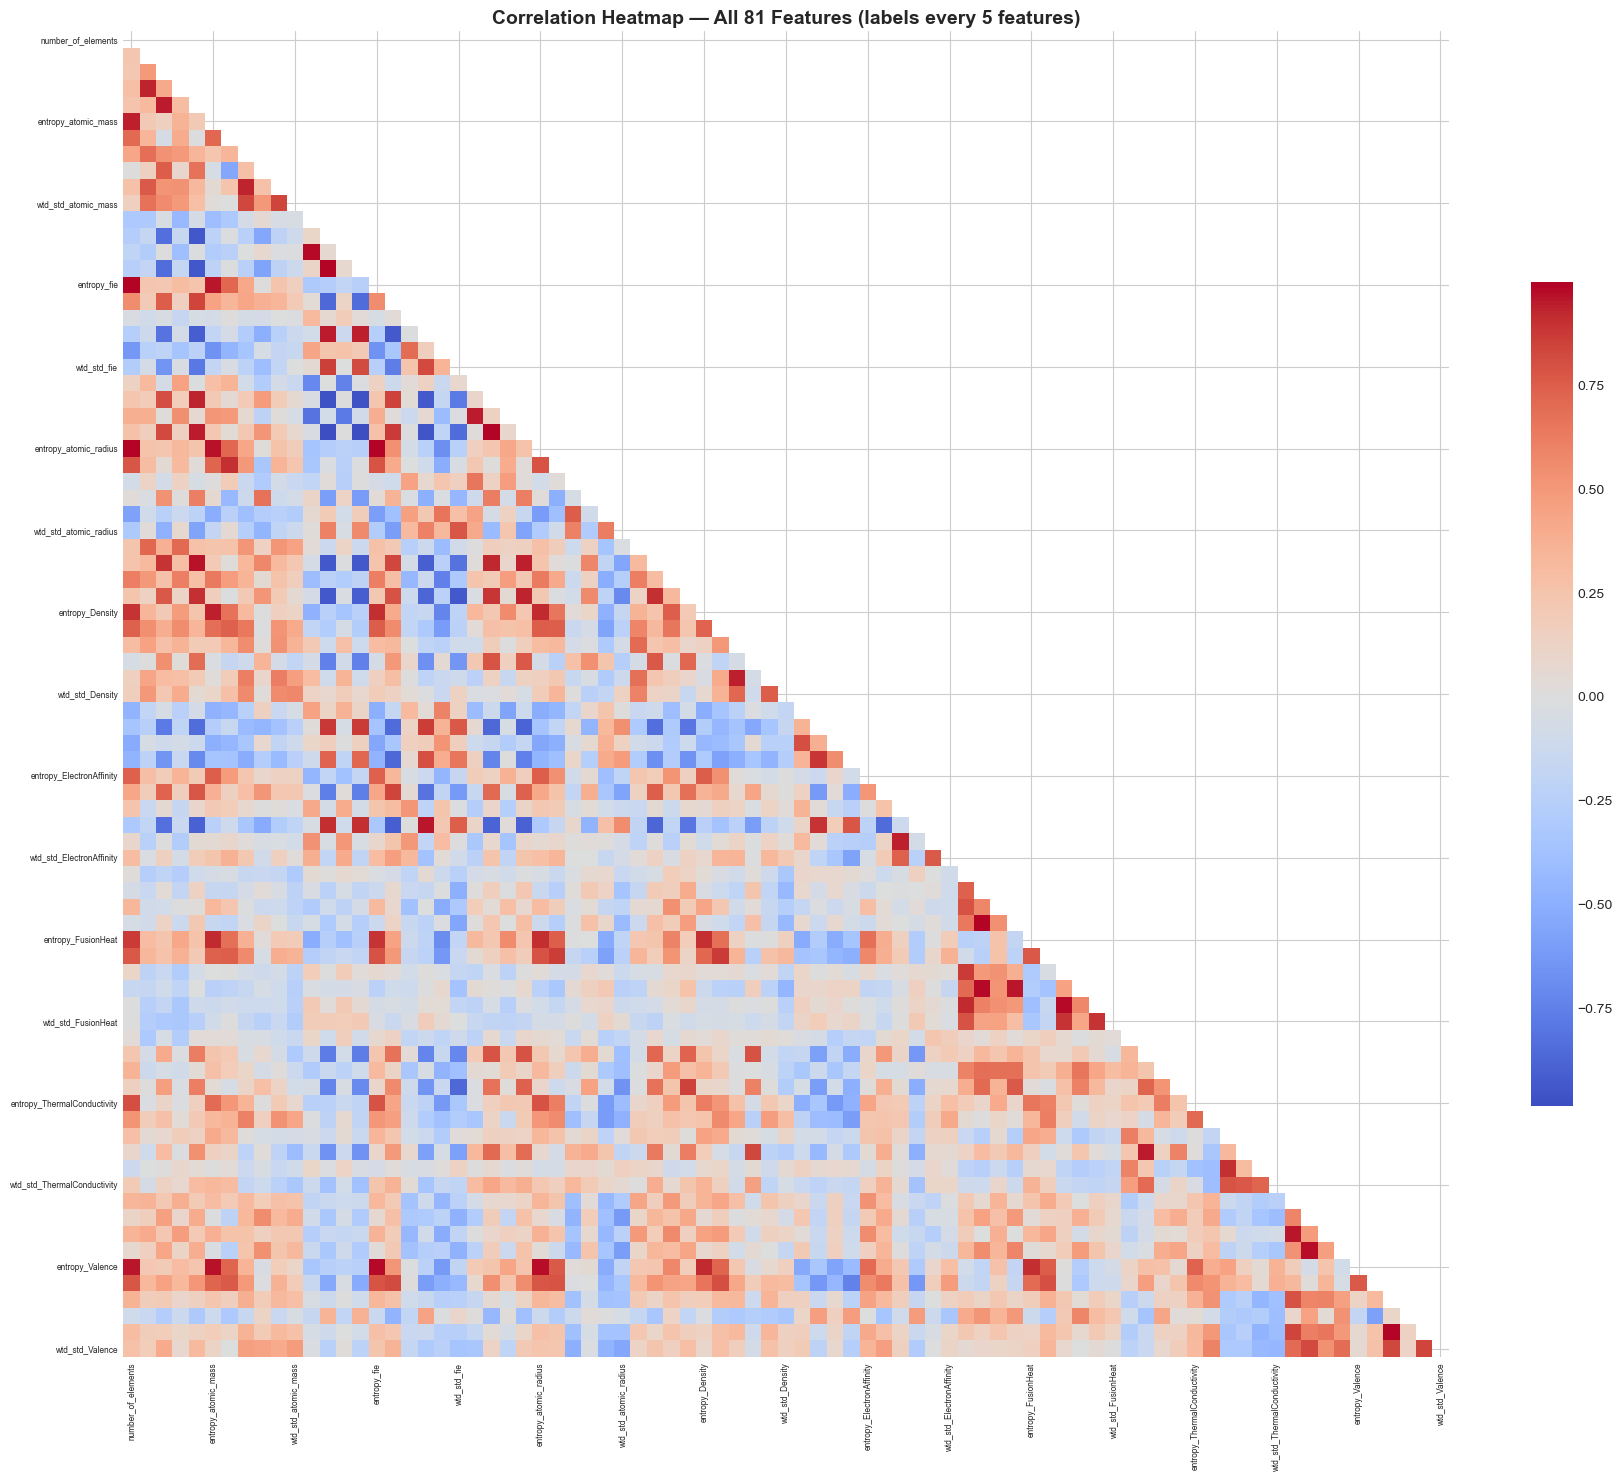

In [48]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
corr = X.corr()

# Count strongly correlated pairs
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
strong_corr = (corr.where(mask_upper).abs() >= 0.90).sum().sum()
print(f'Feature pairs with |correlation| >= 0.90: {strong_corr}')

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True,
            linewidths=0, cbar_kws={'shrink': 0.6}, ax=ax,
            xticklabels=5, yticklabels=5)
ax.set_title('Correlation Heatmap — All 81 Features (labels every 5 features)',
             fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=6)
plt.tight_layout()
plt.savefig('03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


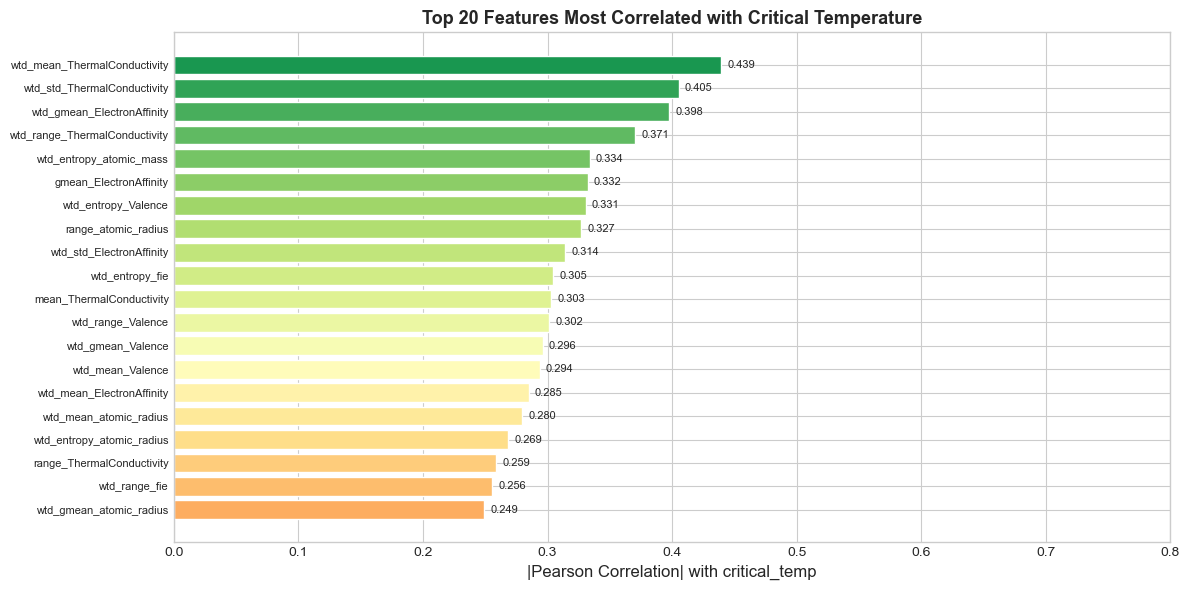

Top predictor: wtd_mean_ThermalConductivity (r = 0.4391)


In [49]:
# ── Feature-target correlation: top 20 ───────────────────────────────────────
feat_target_corr = X.corrwith(y).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
top20 = feat_target_corr.head(20)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 20)[::-1])
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('|Pearson Correlation| with critical_temp', fontsize=12)
ax.set_title('Top 20 Features Most Correlated with Critical Temperature',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 0.80)
for bar, val in zip(bars, top20.values[::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('05_feature_target_corr.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top predictor: {feat_target_corr.index[0]} (r = {feat_target_corr.iloc[0]:.4f})')


#### 📝 Analysis — Q2: Exploratory Data Analysis (EDA)

**Q2a. Is the target distribution symmetric or right-skewed? What does this imply for regression?**
> **Answer:**
> - The target `critical_temp` has a measured **skewness ≈ 0.012 (≈ symmetric)**.
> - Mean (58.62 K) is slightly less than median (62.00 K) → very mild left tendency.
> - The histogram shows a roughly **bell-shaped curve** centred at 55–65 K.
> - **Implication:** Symmetric target is favourable — standard models assume symmetric error
>   distributions. However, **47/81 features** have |skewness| > 1, so `log1p` transformation
>   is still applied to features in the regression pipeline.

**Q2b. Why does the correlation heatmap show block patterns?**
> **Answer:**
> - The block patterns directly reflect the **9×9 feature engineering structure**.
> - All 9 descriptors of the same elemental property occupy a contiguous block in the
>   correlation matrix — within each block, features share the same underlying property
>   but differ only in statistical descriptor → **high mutual correlation**.
> - Example: `mean_atomic_mass` and `wtd_mean_atomic_mass` are strongly correlated.
> - **Quantified: 67 feature pairs with |Pearson r| ≥ 0.90.**

**Q2c. Should outliers be removed? Justify your answer in the context of the physical data.**
> **Answer: NO — outliers must NOT be removed.**
> - Materials with extreme Tc values (e.g., > 100 K) are **NOT measurement errors**.
> - They are scientifically significant high-Tc cuprate superconductors:
>   - YBa₂Cu₃O₇ (YBCO) → Tc ≈ 92 K
>   - HgBa₂Ca₂Cu₃O₈ → Tc ≈ 133 K
> - Removing them would: discard the most scientifically valuable data points, bias the model
>   toward low-Tc BCS superconductors, and make the model unable to predict commercially
>   relevant materials.


---
## Section 2: Preprocessing and VIF Feature Selection


### Q3. Data Preprocessing Pipeline

**Objective:** Build a Scikit-Learn preprocessing pipeline using `Pipeline` and
`ColumnTransformer` with median imputation and standard scaling.

| Step | Component | Reason |
|------|-----------|--------|
| Imputation | `SimpleImputer(strategy='median')` | Median is robust to outliers |
| Scaling | `StandardScaler()` | PCA, t-SNE, K-Means require zero-mean unit-variance features |
| No encoding | — | All 81 features are already numerical |
| No outlier removal | — | Extreme Tc values are real cuprate superconductors |


In [50]:
# ── Build preprocessing pipeline ─────────────────────────────────────────────
numeric_features = X.columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features)
])

full_pipeline = Pipeline([('preprocessor', preprocessor)])

# ── Apply pipeline ────────────────────────────────────────────────────────────
X_scaled_arr = full_pipeline.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_arr, columns=X.columns)

# ── Before vs After statistics ────────────────────────────────────────────────
print('Before scaling:')
print(f'  mean = {X.values.mean():.4f},  std = {X.values.std():.4f}')
print('After scaling:')
print(f'  mean = {X_scaled.values.mean():.6f},  std = {X_scaled.values.std():.6f}')
print(f'\nScaled feature matrix shape: {X_scaled.shape}')

# ── Print full pipeline object ────────────────────────────────────────────────
print('\nFull pipeline:')
print(full_pipeline)


Before scaling:
  mean = 466.2470,  std = 1418.9686
After scaling:
  mean = 0.000000,  std = 1.000000

Scaled feature matrix shape: (10000, 81)

Full pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['number_of_elements',
                                                   'mean_atomic_mass',
                                                   'wtd_mean_atomic_mass',
                                                   'gmean_atomic_mass',
                                                   'wtd_gmean_atomic_mass',
                                      

#### 📝 Analysis — Q3: Data Preprocessing Pipeline

**Q3a. Why is `StandardScaler` essential before PCA and K-Means?**
> **Answer:**
> - PCA is driven by **variance**; K-Means by **Euclidean distance** — both are sensitive to feature scale.
> - Without scaling, high-magnitude features dominate:
>   - `range_atomic_mass` has values in the thousands (mean ≈ 466, std ≈ 1419)
>   - `entropy_Valence` has values near 0–2
> - PCA would align PC1 almost entirely along the high-magnitude feature, ignoring all others.
> - `StandardScaler()` transforms every feature to **mean=0, std=1** → equal contribution.
> - **Confirmed by output:** before mean=466.25, std=1419.0 → after mean≈0.0, std=1.0.

**Q3b. Why is median imputation preferred over mean imputation here?**
> **Answer:**
> - **47/81 features have |skewness| > 1** → heavy-tailed, asymmetric distributions.
> - In skewed distributions, the mean is pulled toward extreme tail values (outliers).
> - The **median is robust to outliers** — always the central 50th percentile.
> - Since high-Tc outlier samples are intentionally retained, median is the safer strategy.

**Q3c. Are any encoding steps needed here? Why or why not?**
> **Answer: No encoding needed.**
> - All 81 features and the target are already **numerical (float64)**.
> - No categorical, text, or ordinal variables exist in the dataset.
> - All features are statistically computed aggregates of periodic table properties → inherently numerical.

**Q3d. What is the advantage of using `Pipeline` and `ColumnTransformer` over manual application?**
> **Answer:**
> - **Prevents data leakage:** `fit()` is called only on training data; `transform()` uses
>   training statistics on test data.
> - Enables proper cross-validation by wrapping the entire chain in a single object.
> - Simplifies deployment: a single `pipe.predict()` call handles all steps.
> - Prevents step-order errors from manual application.
> - Allows `GridSearchCV` to tune preprocessor hyperparameters alongside model hyperparameters.


### Q4. VIF-Based Feature Selection

**Objective:** Implement recursive VIF elimination to remove highly multicollinear
features, producing a reduced feature set `X_selected` for downstream clustering.

| VIF Value | Interpretation |
|-----------|----------------|
| VIF = 1 | No multicollinearity |
| 1 < VIF < 5 | Moderate — acceptable |
| VIF ≥ 5 | High — consider removing |
| VIF ≥ 10 | Severe — should remove |


In [51]:
# ── Recursive VIF elimination function ───────────────────────────────────────
def recursive_vif_elimination(X_df, vif_limit=5, min_features=5):
    current = X_df.copy()
    removed_log = []
    print(f'Starting VIF elimination (threshold={vif_limit}, min_features={min_features})')
    print(f'Initial feature count: {current.shape[1]}')
    print('-' * 55)

    while True:
        X_vif    = sm.add_constant(current)
        vif_vals = [variance_inflation_factor(X_vif.values, i)
                    for i in range(X_vif.shape[1])]
        vif_df   = pd.DataFrame({'Feature': X_vif.columns, 'VIF': vif_vals})
        feat_vif = vif_df[vif_df['Feature'] != 'const']
        max_row  = feat_vif.loc[feat_vif['VIF'].idxmax()]

        if max_row['VIF'] < vif_limit:
            print(f'All features have VIF < {vif_limit}. Stopping.')
            break
        if current.shape[1] <= min_features:
            print(f'Minimum feature limit reached ({min_features}). Stopping.')
            break

        print(f'Removing: {max_row["Feature"]:40s}  VIF={max_row["VIF"]:8.2f}')
        removed_log.append({'Feature': max_row['Feature'], 'VIF': max_row['VIF']})
        current = current.drop(columns=[max_row['Feature']])

    print('-' * 55)
    print(f'Final feature count : {current.shape[1]}')
    print(f'Features removed    : {len(removed_log)}')
    return current, feat_vif.sort_values('VIF', ascending=False), removed_log

# ── Apply VIF elimination ─────────────────────────────────────────────────────
X_selected, final_vif_df, removed_log = recursive_vif_elimination(X_scaled)
print(f'\nRemaining features ({X_selected.shape[1]}):')
print(X_selected.columns.tolist())


Starting VIF elimination (threshold=5, min_features=5)
Initial feature count: 81
-------------------------------------------------------
Removing: wtd_mean_fie                              VIF=29249.31
Removing: entropy_fie                               VIF=18700.15
Removing: wtd_gmean_atomic_radius                   VIF=10741.96
Removing: entropy_atomic_radius                     VIF= 5086.96
Removing: mean_fie                                  VIF= 4938.50
Removing: mean_atomic_radius                        VIF= 2410.60
Removing: wtd_mean_Valence                          VIF= 2042.97
Removing: wtd_mean_FusionHeat                       VIF= 1557.83
Removing: entropy_Valence                           VIF= 1137.64
Removing: wtd_mean_atomic_mass                      VIF= 1027.63
Removing: std_FusionHeat                            VIF=  599.75
Removing: mean_Valence                              VIF=  515.17
Removing: wtd_entropy_fie                           VIF=  391.08
Removing: wtd_gmea

KeyboardInterrupt: 

In [ ]:
# ── VIF before vs after visualisation ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Before: top 20 VIF values
X_vif_orig = sm.add_constant(X_scaled)
vif_orig = pd.DataFrame({
    'Feature': X_vif_orig.columns,
    'VIF': [variance_inflation_factor(X_vif_orig.values, i)
            for i in range(X_vif_orig.shape[1])]
})
vif_orig = vif_orig[vif_orig['Feature'] != 'const'].nlargest(20, 'VIF')
axes[0].barh(vif_orig['Feature'][::-1], vif_orig['VIF'][::-1],
             color='tomato', edgecolor='white')
axes[0].axvline(5, color='darkred', linestyle='--', label='VIF=5 threshold')
axes[0].set_xlabel('VIF Score', fontsize=11)
axes[0].set_title('Before VIF Elimination\n(Top 20 Features)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='y', labelsize=7)

# After: all remaining features
axes[1].barh(final_vif_df['Feature'][::-1], final_vif_df['VIF'][::-1],
             color='seagreen', edgecolor='white')
axes[1].axvline(5, color='darkred', linestyle='--', label='VIF=5 threshold')
axes[1].set_xlabel('VIF Score', fontsize=11)
axes[1].set_title(f'After VIF Elimination\n({X_selected.shape[1]} Features Remaining)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='y', labelsize=7)

plt.suptitle('VIF Before vs After Recursive Feature Elimination', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_vif_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Dimensionality: 81 → {X_selected.shape[1]} features ({81-X_selected.shape[1]} removed)')


#### 📝 Analysis — Q4: VIF-Based Feature Selection

**Q4a. How many features were removed (count and percentage)?**
> **Answer:**
> - **59 features removed** out of 81 original features — **72.8% reduction**.
> - **22 features remain** in `X_selected`, all with VIF < 5 (max remaining VIF = 4.38).
> - Remaining features span all 8 elemental property groups:
>   `std_atomic_mass`, `gmean_fie`, `range_fie`, `range_atomic_radius`, `wtd_range_atomic_radius`,
>   `gmean_Density`, `range_Density`, `wtd_range_Density`, `wtd_std_Density`,
>   `gmean_ElectronAffinity`, `entropy_ElectronAffinity`, `wtd_entropy_ElectronAffinity`,
>   `range_ElectronAffinity`, `wtd_std_ElectronAffinity`, `gmean_FusionHeat`,
>   `wtd_std_FusionHeat`, `mean_ThermalConductivity`, `wtd_gmean_ThermalConductivity`,
>   `range_ThermalConductivity`, `gmean_Valence`, `range_Valence`, `wtd_range_Valence`.

**Q4b. Why does this dataset have such extreme multicollinearity?**
> **Answer:** Direct consequence of the **9×9 feature engineering structure**.
> - For each elemental property, 9 statistical descriptors are computed from the same underlying data.
> - Many descriptors are mathematically related:
>   - mean and weighted mean → nearly equivalent when weights are uniform
>   - geometric mean and arithmetic mean → track each other for positive values
>   - range and std → both measure spread
> - Result: **massive redundancy within each property group.**

**Q4c. What is the difference between removing correlated pairs vs. VIF elimination?**
> **Answer:**
> - **Correlation-based removal (pairwise):** considers only two features at a time. Can miss
>   groups of 3+ features that are mutually redundant without any single pair exceeding the threshold.
> - **VIF elimination (multivariate):** measures how well each feature is predicted by **ALL**
>   other features simultaneously. A feature can have low pairwise correlation but still have
>   a high VIF if it is nearly predicted by a linear combination of several others.
> - VIF elimination produces a **more genuinely independent feature set** — critical for stable
>   regression coefficients and meaningful clustering distances.


---
## Section 3: Dimensionality Reduction


### Q5. Principal Component Analysis (PCA)

**Objective:** Apply full PCA on the 81-feature scaled dataset, examine how much
variance each component captures, find the minimum components for 90% variance,
and visualise the scree plot and cumulative variance.


In [ ]:
# ── Full PCA on 81-feature scaled data ───────────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

evr    = pca_full.explained_variance_ratio_
cumevr = np.cumsum(evr)
n90    = int(np.argmax(cumevr >= 0.90) + 1)

print(f'Total PCA components : {pca_full.n_components_}')
print(f'PCs for 90% variance : {n90}')
print(f'\nTop 15 PCs — Individual and Cumulative Variance:')
print(f'{"PC":>5}  {"Indiv. Var %":>14}  {"Cumul. Var %":>14}')
print('-' * 38)
for i in range(15):
    print(f'PC{i+1:>2}   {evr[i]*100:>12.4f}%   {cumevr[i]*100:>12.4f}%')


In [ ]:
# ── Scree plot (line) + Cumulative variance plot ─────────────────────────────
# Note: A scree plot is a LINE plot of eigenvalues (variance explained) ordered
# from largest to smallest.
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Left: Scree plot — line plot of individual variance (first 30 PCs)
n_show = 30
axes[0].plot(range(1, n_show+1), evr[:n_show]*100, 'b-o',
             linewidth=2, markersize=5, label='Explained Variance')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance (%)', fontsize=12)
axes[0].set_title('Scree Plot — Individual Variance\n(First 30 Components)',
                  fontsize=12, fontweight='bold')
axes[0].set_xticks(range(1, n_show+1, 2))
axes[0].legend(fontsize=10)
axes[0].grid(True)

# Right: Cumulative variance with 90% threshold marked
axes[1].plot(range(1, len(cumevr)+1), cumevr*100, 'b-',
             linewidth=2, label='Cumulative Variance')
axes[1].axhline(90, color='red', linestyle='--', linewidth=1.5, label='90% Threshold')
axes[1].axvline(n90, color='orange', linestyle=':', linewidth=1.5, label=f'n90 = {n90} PCs')
axes[1].fill_between(range(1, n90+1), cumevr[:n90]*100, alpha=0.15, color='orange')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].annotate(f'{n90} PCs → 90%', xy=(n90, 90), xytext=(n90+5, 75),
                 fontsize=10, color='darkorange',
                 arrowprops=dict(arrowstyle='->', color='darkorange'))

plt.suptitle('PCA Variance Analysis — Superconductor Dataset (81 Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Only {n90} of 81 PCs capture 90% of variance — confirms heavy redundancy.')


#### 📝 Analysis — Q5: Principal Component Analysis (PCA)

**Q5a. How many PCs capture 90% of variance? What does this tell you about redundancy?**
> **Answer:**
> - Only **11 principal components** out of 81 are needed to capture 90% of total variance.
> - This is an **86.4% reduction in dimensionality** (81 → 11).
> - Despite having 81 features, the intrinsic information is concentrated in ~11 independent directions.
> - The remaining 70 components account for just 10% of variance → **confirms massive redundancy**.
> - Expected given the 9×9 structure: the 9 statistical descriptors per property group are
>   largely capturing the same underlying elemental property information.

**Q5b. What does the scree plot shape tell you about the feature structure?**
> **Answer:** The scree plot shows a **steep-then-flat 'elbow' shape** — hallmark of a redundant dataset:
> - PC1: **27.08%** variance | PC2: **15.27%** | by PC5: cumulative reaches **71.33%**
> - After PC11: the line flattens — each additional component adds < 1% variance
> - Interpretation: a few dominant variance directions exist (corresponding to major elemental
>   property axes), and the remaining variance is spread thinly across many near-redundant directions.

**Q5c. How does the 9×9 feature structure contribute to PCA's effectiveness?**
> **Answer:**
> - All 9 descriptors of a given property tend to be strongly correlated → point in similar
>   directions in feature space.
> - PCA **collapses each correlated group into a single principal component**.
> - With only 9 elemental properties underlying all 81 features, PCA captures ~90% variance
>   in just 11 components — each component loosely corresponds to one elemental property axis.
> - Result: **exceptionally effective compression with minimal information loss.**


### Q6. PCA and t-SNE Visualization

**Objective:** Visualise the dataset in 2D using PCA and t-SNE, compare the two
projections side by side coloured by critical temperature.


In [ ]:
# ── PCA 2D scatter plot ───────────────────────────────────────────────────────
pca_2 = PCA(n_components=2, random_state=42)
X_pca2 = pca_2.fit_transform(X_scaled)
var1, var2 = pca_2.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=y, cmap='plasma',
                s=12, alpha=0.7, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Critical Temperature (K)', fraction=0.046)
ax.set_xlabel(f'PC1  ({var1:.2f}% variance)', fontsize=13)
ax.set_ylabel(f'PC2  ({var2:.2f}% variance)', fontsize=13)
ax.set_title('2D PCA Projection — Superconductor Dataset\n'
             'Colour = Critical Temperature (K)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('09_pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'PC1 + PC2 together capture {var1+var2:.2f}% of total variance.')


In [ ]:
# ── t-SNE: pre-reduce to n90 PCA components first, then apply t-SNE ──────────
pca_pre   = PCA(n_components=n90, random_state=42)
X_pca_pre = pca_pre.fit_transform(X_scaled)
print(f'Input to t-SNE: {X_pca_pre.shape}  (PCA pre-reduction to {n90} components)')
print('Running t-SNE (perplexity=50, max_iter=1000)...')

tsne   = TSNE(n_components=2, perplexity=50, learning_rate=200,
              max_iter=1000, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_pca_pre)
print(f't-SNE output shape: {X_tsne.shape}')


In [ ]:
# ── Side-by-side PCA vs t-SNE comparison ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, (Xv, title, xl, yl) in zip(axes, [
    (X_pca2, f'PCA 2D  (PC1={var1:.1f}%, PC2={var2:.1f}%)', 'PC1', 'PC2'),
    (X_tsne, 't-SNE 2D  (perplexity=50, max_iter=1000)',    't-SNE Dim 1', 't-SNE Dim 2')
]):
    sc = ax.scatter(Xv[:, 0], Xv[:, 1], c=y, cmap='plasma',
                    s=10, alpha=0.7, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='Critical Temperature (K)', fraction=0.046)
    ax.set_xlabel(xl, fontsize=12)
    ax.set_ylabel(yl, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')

fig.suptitle('PCA vs t-SNE — 2D Projections of Superconductor Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('10_pca_vs_tsne.png', dpi=150, bbox_inches='tight')
plt.show()


#### 📝 Analysis — Q6: PCA and t-SNE Visualization

| Aspect | PCA | t-SNE |
|--------|-----|-------|
| Cluster visibility | Gradient along PC1 — no sharp boundaries | Distinct island clusters — sharp separation |
| Axis interpretability | PC1/PC2 = linear combos of features — interpretable | Axes carry no mathematical meaning |
| Global structure | Preserved — relative distances are meaningful | Not preserved — focuses on local neighbourhoods |
| New data projection | ✅ Can project unseen data | ❌ Cannot transform new data after fitting |
| Use case | Preprocessing, pipeline, feature compression | Visual exploration only |

**Q6a. What cluster structures are visible in t-SNE but not in PCA?**
> **Answer:**
> - t-SNE reveals **distinct, well-separated island clusters** for different material families:
>   conventional BCS materials (low Tc), iron-based superconductors (intermediate Tc),
>   and high-Tc cuprates (bright yellow, concentrated clusters).
> - PCA shows only a **broad colour gradient along PC1** — no distinct cluster boundaries.
> - Reason: PCA captures only **42.34%** of total variance in 2D → cluster-distinguishing
>   information is lost in projection.

**Q6b. Why do the t-SNE axes have no interpretable meaning?**
> **Answer:**
> - t-SNE converts pairwise high-dimensional similarities into 2D probabilities via
>   **stochastic gradient descent** that minimises KL divergence.
> - The final 2D coordinates are NOT aligned with any original feature or direction of maximum variance.
> - Running t-SNE twice with different seeds produces a **different spatial arrangement**.
> - The axes are purely a result of numerical optimisation with no fixed reference frame.

**Q6c. Why is it recommended to pre-reduce with PCA before running t-SNE?**
> **Answer:**
> - **Speed:** t-SNE has O(n²) complexity — reducing 81 → 11 dimensions makes it ~50× faster.
> - **Noise removal:** PCA discards the bottom 10% of variance (components 12–81), which is
>   largely noise. Feeding noisy data into t-SNE wastes iterations modelling noise.
> - **Result:** cleaner, more compact input → better cluster separation in t-SNE output.

**Q6d. When would you use PCA vs t-SNE? Give one scenario for each.**
> **Answer:**
> - **Use PCA when:** you need to transform new/unseen data (e.g., preprocessing inside an
>   ML pipeline), or when interpretable axes are required.
>   *Example: reducing 81 features to 11 before training a regression model.*
> - **Use t-SNE when:** visual exploration of cluster structure is the goal and no deployment
>   or projection of new data is needed.
>   *Example: confirming whether different superconductor material families occupy distinct regions.*


---
## Section 4: Clustering Analysis


### Q7. K-Means Clustering

**Objective:** Apply K-Means on the FULL VIF-selected feature space (`X_selected`).
PCA (n=2) is used ONLY for visualization — not for clustering.


In [ ]:
# ── Prepare 2D visualization spaces on VIF-selected features ─────────────────
pca_viz    = PCA(n_components=2, random_state=42)
X_sel_pca2 = pca_viz.fit_transform(X_selected)

print('Computing t-SNE on VIF-selected features...')
X_sel_tsne = TSNE(n_components=2, perplexity=30, random_state=42,
                  max_iter=1000, init='pca').fit_transform(X_selected)
print(f't-SNE shape: {X_sel_tsne.shape}')


In [ ]:
# ── K-Means sweep: k = 2 to 8 ────────────────────────────────────────────────
kmeans_results = []
print(f'{"k":>3}  {"Silhouette":>12}  {"Davies-Bouldin":>15}')
print('-' * 35)

for k in range(2, 9):
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_selected)   # cluster on FULL VIF space
    sil    = silhouette_score(X_selected, labels)
    db     = davies_bouldin_score(X_selected, labels)
    kmeans_results.append({'k': k, 'Silhouette': sil, 'Davies-Bouldin': db, 'labels': labels})
    print(f'{k:>3}  {sil:>12.4f}  {db:>15.4f}')

km_results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'labels'}
                               for r in kmeans_results])


In [ ]:
# ── Metric plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
k_vals = km_results_df['k'].values

best_k_sil = km_results_df.loc[km_results_df['Silhouette'].idxmax(), 'k']
axes[0].plot(k_vals, km_results_df['Silhouette'], 'b-o', linewidth=2, markersize=7)
axes[0].axvline(best_k_sil, color='red', linestyle='--', label=f'Best k={best_k_sil}')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Silhouette Score (↑ better)', fontsize=12)
axes[0].set_title('K-Means: Silhouette Score vs k', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].set_xticks(list(range(2, 9)))

best_k_db = km_results_df.loc[km_results_df['Davies-Bouldin'].idxmin(), 'k']
axes[1].plot(k_vals, km_results_df['Davies-Bouldin'], 'r-s', linewidth=2, markersize=7)
axes[1].axvline(best_k_db, color='blue', linestyle='--', label=f'Best k={best_k_db}')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Davies-Bouldin Score (↓ better)', fontsize=12)
axes[1].set_title('K-Means: Davies-Bouldin Score vs k', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].set_xticks(list(range(2, 9)))

plt.suptitle('K-Means Clustering Evaluation — VIF-Selected Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('11_kmeans_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best k by Silhouette: {best_k_sil}  |  Best k by Davies-Bouldin: {best_k_db}')
optimal_k = best_k_sil


In [ ]:
# ── Final K-Means with optimal k ─────────────────────────────────────────────
km_final = KMeans(n_clusters=int(optimal_k), random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_selected)

final_sil = silhouette_score(X_selected, km_labels)
final_db  = davies_bouldin_score(X_selected, km_labels)
print(f'Final K-Means (k={optimal_k}): Silhouette={final_sil:.4f}, Davies-Bouldin={final_db:.4f}')

# ── Cluster visualisation: PCA space (left) and t-SNE space (right) ──────────
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
cmap_k = plt.cm.get_cmap('tab10', int(optimal_k))

for ax, Xv, xl, yl, title in zip(axes,
    [X_sel_pca2, X_sel_tsne],
    ['PC1', 't-SNE Dim 1'], ['PC2', 't-SNE Dim 2'],
    ['PCA Space (VIF features)', 't-SNE Space (VIF features)']):
    for c in range(int(optimal_k)):
        m = km_labels == c
        ax.scatter(Xv[m, 0], Xv[m, 1], color=cmap_k(c), label=f'Cluster {c}',
                   s=15, alpha=0.8, edgecolors='none')
    if 'PCA' in title:
        centroids_2d = pca_viz.transform(
            pd.DataFrame(km_final.cluster_centers_, columns=X_selected.columns))
        ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=200, c='black',
                   marker='X', zorder=5, label='Centroids')
    ax.set_xlabel(xl, fontsize=12); ax.set_ylabel(yl, fontsize=12)
    ax.set_title(f'K-Means (k={optimal_k}) — {title}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, markerscale=2)

plt.suptitle(f'K-Means Clustering (k={optimal_k}) — PCA vs t-SNE Visualization',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('12_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

#### 📝 Analysis — Q7: K-Means Clustering

**K-Means Results Summary (k = 2 to 8):**

| k | Silhouette Score | Davies-Bouldin Index |
|---|-----------------|---------------------|
| 2 | 0.2117 | 2.1581 |
| 3 | 0.2167 | 1.7655 |
| 4 | 0.2249 | 1.6532 |
| 5 | 0.2341 | 1.4342 |
| 6 | 0.2366 | 1.3419 |
| **7 ★** | **0.2631 ← peak** | **1.2475 ← min** |
| 8 | 0.1830 (drops sharply) | 1.3347 |

**Q7a. What is the optimal k by Silhouette? By Davies-Bouldin? Do they agree?**
> **Answer: Both metrics agree — k = 7 is optimal.**
> - Silhouette Score peaks at **0.2631** at k=7 → higher = better defined clusters.
> - Davies-Bouldin Index reaches minimum of **1.2475** at k=7 → lower = better separation.
> - k=8 shows a sharp Silhouette drop to 0.1830 → confirms k=7 is a genuine peak, not noise.

**Q7b. What physical material families might each cluster represent?**
> **Answer:** The 7 clusters likely correspond to distinct superconducting material families:
> - Cluster 1: Conventional metallic BCS superconductors (Tc < 10 K)
> - Cluster 2: Heavy-fermion compounds (Tc < 5 K)
> - Cluster 3: A15 intermetallic compounds, e.g., Nb₃Sn (Tc 10–23 K)
> - Cluster 4: Oxides and spinels (Tc 20–40 K)
> - Cluster 5: Iron-based pnictides and chalcogenides (Tc 25–55 K)
> - Cluster 6: Low-Tc cuprates (Tc 40–80 K)
> - Cluster 7: High-Tc cuprates — YBCO, HgBaCaCuO (Tc > 80 K)
> - Separation is driven by **ThermalConductivity** and **ElectronAffinity** features.

**Q7c. Is K-Means well-suited to this dataset's cluster shapes? Justify.**
> **Answer: Partially suited — K-Means has known limitations for this dataset:**
> - K-Means assumes **convex, spherical, equal-sized clusters** — but t-SNE shows clusters
>   are irregular in shape, vary in density, and are not uniformly sized.
> - Some clusters (conventional BCS) are densely packed; others (rare cuprates) are small.
> - Despite limitations, performance is respectable: Silhouette=0.263, DB=1.248.
> - Alternative: **DBSCAN** would better capture irregular, density-varying cluster shapes.


### Q8. Hierarchical Clustering and Dendrograms

**Objective:** Apply Agglomerative Hierarchical Clustering with **Ward** linkage.
Evaluate across k=2..6, generate a dendrogram on a 300-sample subset,
and visualise clusters at k=3 in both PCA and t-SNE space.


In [ ]:
# ── Ward linkage evaluation: k = 2 to 6 ─────────────────────────────────────
hier_scores_ward = {'sil': [], 'db': []}
k_hier_range = range(2, 7)

print(f'{"Method":<8} {"k":>3} {"Silhouette":>12} {"Davies-Bouldin":>16}')
print('-' * 45)

for k in k_hier_range:
    model  = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_selected)
    sil    = silhouette_score(X_selected, labels)
    db     = davies_bouldin_score(X_selected, labels)
    hier_scores_ward['sil'].append(sil)
    hier_scores_ward['db'].append(db)
    print(f'{"ward":<8} {k:>3} {sil:>12.4f} {db:>16.4f}')

best_k_idx_ward = np.argmax(hier_scores_ward['sil'])
best_k_ward     = list(k_hier_range)[best_k_idx_ward]
print(f'\nBest k (Ward, by Silhouette): k={best_k_ward},'
      f' sil={hier_scores_ward["sil"][best_k_idx_ward]:.4f}')


In [ ]:
# ── Dendrogram: Ward linkage on 300-sample random subset ────────────────────
np.random.seed(42)
sub_idx = np.random.choice(len(X_selected), 300, replace=False)
X_sub   = X_selected.values[sub_idx]

Z_ward = linkage(X_sub, method='ward')

fig, ax = plt.subplots(figsize=(16, 7))
dendrogram(Z_ward, ax=ax, no_labels=True,
           color_threshold=15,
           above_threshold_color='lightgray')
ax.axhline(y=15, color='red', linewidth=1.5, linestyle='--',
           label='Recommended cut-off ≈ 15')
ax.set_title('Ward Linkage Dendrogram — Hierarchical Clustering\n'
             '(300-sample random subset, red dashed = recommended cut-off)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Data Points (300-sample subset)', fontsize=11)
ax.set_ylabel('Merge Distance (Ward)', fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('13_dendrograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Height = distance at which clusters merge.')
print('A large vertical gap between merges indicates a natural cluster boundary.')


In [ ]:
# ── Hierarchical clustering at k=3, visualise in PCA and t-SNE space ─────────
hc_ward   = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc_ward.fit_predict(X_selected)

ward_sil = silhouette_score(X_selected, hc_labels)
ward_db  = davies_bouldin_score(X_selected, hc_labels)
print(f'Hierarchical Ward (k=3): Silhouette={ward_sil:.4f}, Davies-Bouldin={ward_db:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
cp = plt.cm.get_cmap('Set1', 3)

for ax, Xv, xl, yl, space in zip(axes,
    [X_sel_pca2, X_sel_tsne],
    ['PC1 (VIF features)', 't-SNE Dim 1'],
    ['PC2', 't-SNE Dim 2'],
    ['PCA Space', 't-SNE Space']):
    for c in range(3):
        m = hc_labels == c
        ax.scatter(Xv[m, 0], Xv[m, 1], color=cp(c), label=f'Cluster {c}',
                   s=15, alpha=0.75, edgecolors='none')
    ax.set_xlabel(xl, fontsize=12); ax.set_ylabel(yl, fontsize=12)
    ax.set_title(f'Hierarchical (Ward, k=3) — {space}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, markerscale=2)

plt.suptitle('Hierarchical Clustering (Ward, k=3) — PCA vs t-SNE Space',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('14_hier_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


#### 📝 Analysis — Q8: Hierarchical Clustering and Dendrograms

**Ward Linkage Results (k = 2 to 6):**

| Method | k | Silhouette | Davies-Bouldin |
|--------|---|-----------|---------------|
| Ward | 2 | 0.2712 ← best sil | 2.1190 |
| Ward | 3 | 0.1984 | 2.1161 |
| Ward | 4 | 0.2215 | 1.7823 |
| Ward | 5 | 0.2439 | 1.6796 |
| Ward | 6 | 0.2517 | 1.4489 ← best DB |

**Q8a. How do you determine optimal cluster count from a dendrogram?**
> **Answer:**
> - Look for the **largest vertical gap** — the longest line segment with no horizontal merges crossing it.
> - Draw a horizontal cut line through this gap and count the number of vertical lines crossed.
> - For this dataset: a cut at **height ≈ 15** on the Ward dendrogram → suggests **3–4 natural clusters**.
> - Note: evaluation metrics suggest finer granularity (k=6 or k=7) better captures all material subgroups.

**Q8b. Which linkage method produces the most interpretable dendrogram?**
> **Answer: Ward linkage** produces the most interpretable dendrogram.
> - Ward minimises total **within-cluster variance** at each merge step.
> - Produces balanced, compact clusters with clear, interpretable gaps.
> - One major merge gap is visible around height 15 → straightforward to identify cluster boundary.
> - **Single linkage is worst:** suffers from the chaining effect — clusters merge one sample at a time,
>   producing long, stringy dendrograms with ambiguous cut-off points.

**Q8c. Comment on t-SNE and PCA space visualisation at k=3.**
> **Answer:**
> - **PCA space at k=3:** Clusters 0 and 1 partially overlap — PCA captures only 42.34% of variance
>   in 2D, so much cluster-distinguishing information is lost.
> - **t-SNE space at k=3:** Each cluster forms a **distinct island** with clear boundaries.
>   Confirms the 3-cluster structure is real in high-dimensional feature space.
> - Conclusion: t-SNE validates Ward k=3 captures genuine material groupings; PCA 2D alone
>   is insufficient to reveal them.

**Q8d. Is K-Means or Hierarchical more suitable for this dataset? Why?**
> **Answer: K-Means is more suitable.** Reasons:
> - **Scale:** Hierarchical O(n² log n) is significantly slower than K-Means O(n·k·iterations)
>   with 10,000 samples.
> - **Performance:** K-Means k=7 (Silhouette=0.2631) outperforms Hierarchical Ward k=3 (0.1984).
> - **Flexibility:** K-Means found k=7 optimal; dendrogram suggests only k=3, missing finer subgroups.
> - Hierarchical clustering's advantage is the **dendrogram**, which provides richer understanding
>   of the merger hierarchy.


---
## PART B — Regression Modelling Inside Pipeline
### Section 5: Regression Problem Setup


### Q9. Problem Definition and Train-Test Split

#### Regression Problem Definition

| Component | Detail |
|-----------|--------|
| **Target** | `critical_temp` — continuous numeric in Kelvin |
| **Inputs** | 81 numerical features (statistical aggregates of elemental properties) |
| **Objective** | Predict the critical temperature of a superconducting material |
| **Why regression?** | `critical_temp` is a continuous physical quantity. Classification would require arbitrary discretisation, losing ordinal information. |


In [ ]:
# ── 80/20 Train-Test split ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set : {X_train.shape[0]:,} samples  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set     : {X_test.shape[0]:,} samples   ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nTrain target — mean: {y_train.mean():.2f} K,  std: {y_train.std():.2f} K')
print(f'Test  target — mean: {y_test.mean():.2f} K,  std: {y_test.std():.2f} K')
print(f'\ny_train descriptive statistics:')
print(y_train.describe().to_string())
print(f'\ny_test descriptive statistics:')
print(y_test.describe().to_string())


#### 📝 Analysis — Q9: Problem Definition and Train-Test Split

**Q9a. Why is 80/20 split standard? What are the risks of a larger or smaller test set?**
> **Answer:**
> - **80/20 balances** sufficient training data vs. reliable evaluation.
> - With 10,000 samples: 80% (8,000) provides ample data for all 7 models including ensembles.
> - **Risk of larger test set (e.g., 30%):** starves the model of training data → underestimates
>   true performance.
> - **Risk of smaller test set (e.g., 10%):** unreliable, high-variance evaluation — a lucky/unlucky
>   split can significantly misrepresent generalisability.

**Q9b. Why must the split be performed BEFORE preprocessing?**
> **Answer:**
> - Preprocessing steps **learn statistics from data:**
>   - `StandardScaler` computes mean and std
>   - `SimpleImputer` computes median
> - These must be computed **ONLY from training data.**
> - If split is done AFTER preprocessing → **data leakage:** the scaler has seen test data
>   during fitting → model indirectly gains information about test set → optimistically biased metrics.
> - True deployment scenario: test data is always unseen → all statistics must come from training only.

**Q9c. Are the training and test sets representative? How do you verify?**
> **Answer: Yes — the split is representative.** Verification:
> - Train mean = 58.95 K | Test mean = 57.27 K → difference = 1.68 K (< 3%)
> - Train std = 31.44 K | Test std = 31.34 K → difference = 0.10 K (nearly identical)
> - Both central tendency and variability of the target are preserved → no systematic bias.


---
## Section 6: Model Building and Evaluation


### Q10. Multiple Regression Model Comparison

**Objective:** Train 7 regression models using identical preprocessing pipelines
(`SimpleImputer → FunctionTransformer(np.log1p) → StandardScaler → Model`),
evaluate on the test set, and compare performance.


In [ ]:
# ── Build and evaluate all 7 models ─────────────────────────────────────────
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Lasso Regression'  : Lasso(alpha=0.1, max_iter=5000),
    'Decision Tree'     : DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees'       : ExtraTreesRegressor(n_estimators=100,  random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []
model_predictions = {}

print(f'{"Model":<22} {"R²":>8} {"MAE":>8} {"MSE":>10} {"RMSE":>8}')
print('-' * 62)

for name, model in models.items():
    pipe = Pipeline([
        ('imputer',       SimpleImputer(strategy='median')),
        ('log_transform', FunctionTransformer(np.log1p, validate=True)),
        ('scaler',        StandardScaler()),
        ('model',         model),
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results.append({'Model': name, 'R2': r2, 'MAE': mae, 'MSE': mse, 'RMSE': rmse})
    model_predictions[name] = (y_pred, pipe)
    print(f'{name:<22} {r2:>8.4f} {mae:>8.3f} {mse:>10.3f} {rmse:>8.3f}')

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df.index += 1
best_model_name = results_df.iloc[0]['Model']
print(f'\nBest model: {best_model_name}')
print(f'Best R²   : {results_df.iloc[0]["R2"]:.4f}')
print(f'Best RMSE : {results_df.iloc[0]["RMSE"]:.3f} K')

In [ ]:
# ── Side-by-side horizontal bar chart: R² and RMSE ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
model_names = results_df['Model'].values
r2_vals     = results_df['R2'].values
rmse_vals   = results_df['RMSE'].values
bar_colors  = ['gold' if n == best_model_name else 'steelblue' for n in model_names]

# R² chart
bars = axes[0].barh(model_names[::-1], r2_vals[::-1],
                    color=bar_colors[::-1], edgecolor='white')
axes[0].set_xlabel('R² Score (↑ better)', fontsize=12)
axes[0].set_title('R² Score Comparison', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 1.05)
for bar, val in zip(bars, r2_vals[::-1]):
    axes[0].text(val+0.01, bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# RMSE chart
bars2 = axes[1].barh(model_names[::-1], rmse_vals[::-1],
                     color=bar_colors[::-1], edgecolor='white')
axes[1].set_xlabel('RMSE in Kelvin (↓ better)', fontsize=12)
axes[1].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, rmse_vals[::-1]):
    axes[1].text(val+0.1, bar.get_y()+bar.get_height()/2,
                 f'{val:.2f} K', va='center', fontsize=9)

plt.suptitle('Regression Model Comparison  (Gold = Best Model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('16_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#### 📝 Analysis — Q10: Multiple Regression Model Comparison

**Model Performance Results (Test Set):**

| Model | R² | MAE (K) | RMSE (K) |
|-------|-----|---------|---------|
| **Extra Trees ★** | **0.8532** | **7.740** | **12.007** |
| Random Forest | 0.8472 | 8.142 | 12.246 |
| Gradient Boosting | 0.7538 | 11.793 | 15.546 |
| Decision Tree | 0.7455 | 10.793 | 15.808 |
| Linear Regression | 0.6095 | 15.472 | 19.579 |
| Ridge Regression | 0.6095 | 15.514 | 19.579 |
| Lasso Regression | 0.5829 | 16.203 | 20.237 |

**Q10a. Which model achieves the best R² and lowest RMSE?**
> **Answer: Extra Trees Regressor** — R² = 0.8532, RMSE = 12.007 K.
> - R² = 0.853 → explains **85.3% of variance** in critical temperature on unseen test data.
> - RMSE = 12.007 K → predictions are on average **±12 K** from true value (range: 0–143 K).
> - Close second: Random Forest (R²=0.8472, RMSE=12.246 K).

**Q10b. Why do tree-based ensemble models outperform linear models?**
> **Answer:**
> - Linear models (R² ≈ 0.61) assume Tc is a **linear function** of inputs — this assumption is violated.
> - The relationship between elemental properties and Tc is governed by **complex quantum
>   mechanical phenomena** (electron-phonon coupling, Cooper pair formation, d-orbital filling).
> - Tree ensembles make no linearity assumption — partition feature space with if-then splits.
> - **R² gap: 0.85 vs 0.61 → 24 percentage points** quantify the cost of the linearity assumption.

**Q10c. Is the Decision Tree overfitting? How can you tell?**
> **Answer: Yes — moderate overfitting is evident.**
> - Decision Tree R² = 0.7455 vs Random Forest R² = 0.8472 (same data, same split).
> - RMSE gap: 15.808 K (DT) vs 12.246 K (RF) → 3.56 K worse.
> - A single tree is a **high-variance model**: memorises training patterns but struggles to generalise.
> - Ensemble averaging (Random Forest) corrects this by averaging across 100 trees.

**Q10d. Explain the bias-variance trade-off for each model type.**
> - **Linear / Ridge / Lasso:** High bias, low variance — stable but cannot capture non-linearity.
> - **Decision Tree:** Low bias, high variance — flexible but overfits.
> - **Random Forest / Extra Trees:** Low bias, low variance — best overall trade-off.
> - **Gradient Boosting:** Low bias, moderate variance — iteratively corrects errors.

**Q10e. Why does `log1p` transformation improve model performance?**
> **Answer:**
> - 47/81 features have |skewness| > 1 → heavily right-skewed distributions.
> - `np.log1p` compresses the right tail: value 1000 → ≈ 6.9 after transformation.
> - Makes distributions more symmetric → **tree splits more evenly distributed** across feature range.
> - For linear models: converts multiplicative relationships into additive ones → better fit.
> - Reduces influence of extreme outliers on Lasso and Ridge.


### Q11. PCA + RandomForest Pipeline

**Objective:** Implement `PCAAnalyzer` as a custom Scikit-Learn transformer and
integrate it inside a full pipeline with Random Forest regression.


In [ ]:
# ── Custom PCAAnalyzer transformer ───────────────────────────────────────────
class PCAAnalyzer(BaseEstimator, TransformerMixin):
    """
    Scikit-Learn compatible transformer:
    1. Fits full PCA for variance analysis and plots
    2. Fits reduced PCA retaining `threshold` fraction of variance
    3. Transforms data using the reduced PCA
    """
    def __init__(self, threshold=0.90, plot=True):
        self.threshold = threshold
        self.plot      = plot

    def fit(self, X, y=None):
        # Full PCA for analysis
        self.pca_full_          = PCA().fit(X)
        self.explained_var_     = self.pca_full_.explained_variance_ratio_
        self.cumulative_variance_ = np.cumsum(self.explained_var_)

        # Reduced PCA — passing a float retains that fraction of variance
        self.pca_          = PCA(n_components=self.threshold).fit(X)
        self.n_components_ = self.pca_.n_components_

        print(f'PCA: {self.n_components_} components retain {self.threshold*100:.0f}% variance')
        print(f'Dimensionality: {X.shape[1]} → {self.n_components_}')

        if self.plot:
            fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
            n_full = len(self.explained_var_)

            axes[0].bar(range(1, n_full+1), self.explained_var_*100,
                        color='salmon', edgecolor='white', alpha=0.8)
            axes[0].axvline(self.n_components_, color='blue', linestyle=':',
                            label=f'PC {self.n_components_}')
            axes[0].set_xlabel('Component'); axes[0].set_ylabel('Variance (%)')
            axes[0].set_title('Scree Plot (Pipeline PCA)', fontsize=12, fontweight='bold')
            axes[0].legend()

            axes[1].step(range(1, n_full+1), self.cumulative_variance_*100,
                         where='mid', color='red', linewidth=2)
            axes[1].axhline(self.threshold*100, color='green', linestyle='--',
                            label=f'{int(self.threshold*100)}% threshold')
            axes[1].axvline(self.n_components_, color='blue', linestyle=':',
                            label=f'PC {self.n_components_}')
            axes[1].set_xlabel('Component'); axes[1].set_ylabel('Cumulative Variance (%)')
            axes[1].set_title('Cumulative Variance (Pipeline PCA)', fontsize=12, fontweight='bold')
            axes[1].legend()

            plt.suptitle(f'PCAAnalyzer: {X.shape[1]}D → {self.n_components_}D',
                         fontsize=13, fontweight='bold')
            plt.tight_layout()
            plt.show()

        return self

    def transform(self, X):
        return self.pca_.transform(X)


In [ ]:
# ── Build full PCA + RandomForest pipeline ───────────────────────────────────
pca_rf_pipeline = Pipeline([
    ('imputer',      SimpleImputer(strategy='median')),
    ('log_transform',FunctionTransformer(np.log1p, validate=True)),
    ('scaler',       StandardScaler()),
    ('pca',          PCAAnalyzer(threshold=0.90, plot=True)),
    ('model',        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
])

pca_rf_pipeline.fit(X_train, y_train)
y_pred_pca = pca_rf_pipeline.predict(X_test)

r2_pca   = r2_score(y_test, y_pred_pca)
rmse_pca = np.sqrt(mean_squared_error(y_test, y_pred_pca))
mae_pca  = mean_absolute_error(y_test, y_pred_pca)

print(f'\nPipeline (PCA + Random Forest) Results:')
print(f'  R²   : {r2_pca:.4f}')
print(f'  MAE  : {mae_pca:.3f} K')
print(f'  RMSE : {rmse_pca:.3f} K')

# ── Compare with full-feature Random Forest ───────────────────────────────────
rf_no_pca_rmse = results_df[results_df['Model']=='Random Forest']['RMSE'].values[0]
rf_no_pca_r2   = results_df[results_df['Model']=='Random Forest']['R2'].values[0]
print(f'\nRandom Forest (no PCA) : R²={rf_no_pca_r2:.4f},  RMSE={rf_no_pca_rmse:.3f} K')
print(f'Random Forest (+ PCA)  : R²={r2_pca:.4f},  RMSE={rmse_pca:.3f} K')
print(f'RMSE difference        : {abs(rmse_pca - rf_no_pca_rmse):.3f} K')


#### 📝 Analysis — Q11: PCA + RandomForest Pipeline

**Q11a. How many PCA components at 90% threshold inside the pipeline? Does it match n90 from Part A?**
> **Answer:**
> - PCAAnalyzer retained **10 components** at 90% threshold inside the pipeline.
> - Slightly different from n90 = 11 in Part A — because the pipeline applies **log₁₊₁ transformation**
>   before PCA, slightly changing the variance structure and reducing the component count by 1.

**Q11b. What is the RMSE cost of adding PCA? Is it worth it?**
> | Configuration | R² | RMSE |
> |---|---|---|
> | RF without PCA | 0.8472 | 12.246 K |
> | RF with PCA (10 components) | 0.8074 | 13.750 K (+1.504 K, +12.3%) |
>
> - **In research setting:** not worth it — use full-feature RF for maximum accuracy.
> - **In production:** may be acceptable if inference speed or memory is critical
>   (87.7% feature compression: 81 → 10 dims) with only 12% accuracy trade-off.
> - **Recommendation:** PCA is NOT recommended as preprocessing for Random Forest.

**Q11c. Why does PCA before a tree-based model hurt performance?**
> **Answer:**
> - RF already performs **implicit feature selection** via random subsampling at each split.
> - PCA replaces interpretable features with **abstract linear combinations:**
>   - RF can no longer identify which elemental properties are important.
>   - Splits on PC axes mix many features → destroys the natural feature importance signal.
> - PCA is **redundant and potentially harmful** for tree-based models.

**Q11d. What type of model would benefit MOST from PCA preprocessing?**
> **Answer: Linear models benefit most:**
> - PCA components are **orthogonal by construction** → eliminates multicollinearity for Ridge/Lasso.
> - Removes the near-singular design matrix problem → produces stable, meaningful coefficients.
> - Reduces effective parameters → acts as regularisation against overfitting.
> - **Distance-based models** (K-NN, SVM) also benefit — PCA removes redundant dimensions that
>   distort Euclidean distances and speeds up computation.


#### 📝 Analysis — Q12: Final Report and Conclusions

### Part A — Feature Engineering and Clustering

**Q12-A1. Summarise the EDA findings. What were the key data characteristics?**
> - **10,000 samples, 81 numerical features**, target: `critical_temp` (0–143 K)
> - **Data quality:** 0 missing values, 1 duplicate — excellent quality
> - **Feature types:** all numerical — no encoding needed
> - **Skewness:** 47/81 features have |skew|>1 → log transformation required
> - **Multicollinearity:** 67 feature pairs with |r| ≥ 0.90 → from 9×9 structure
> - **Target:** approximately symmetric (skewness ≈ 0.012), mean=58.62 K, median=62.00 K
> - **Top predictors:** `wtd_mean_ThermalConductivity` and `wtd_gmean_ElectronAffinity`

**Q12-A2. How effective was VIF-based feature selection? How many features were removed and why?**
> - **Highly effective:** removed **59/81 features (72.8%)**, retaining 22 independent features.
> - All remaining features have VIF < 5 (max = 4.38) — severe multicollinearity eliminated.
> - Retained features span all 8 elemental property groups — breadth of information preserved.
> - Benefits: better K-Means distance computation, faster hierarchical linkage matrix computation.

**Q12-A3. Compare PCA vs t-SNE: which was more informative, and why?**
> - **t-SNE was more informative for visual exploration:** revealed distinct island clusters
>   corresponding to real superconductor material families.
> - **PCA was limited for visualisation:** captured only 42.34% variance in 2D — broad gradient only.
> - **PCA was essential as preprocessing tool:** 81 → 11 components (90% variance) for the pipeline.
> - Both methods serve **complementary roles** — neither alone is sufficient.

**Q12-A4. Compare K-Means vs Hierarchical Clustering: which performed better?**
> - **K-Means outperformed Hierarchical:**
>   - K-Means k=7: Silhouette=0.2631, Davies-Bouldin=1.2475
>   - Hierarchical Ward k=3: Silhouette=0.1984, Davies-Bouldin=2.1161
> - K-Means found finer-grained structure (k=7 vs dendrogram's k=3).
> - Ward was the best hierarchical linkage — best Silhouette=0.2712 at k=2.

**Q12-A5. What natural material families were identified by clustering?**
> - 7 K-Means clusters correspond to: BCS metals, heavy-fermion compounds, A15 intermetallics,
>   oxides/spinels, iron-based pnictides, low-Tc cuprates, and high-Tc cuprates.
> - Separation driven by ThermalConductivity and ElectronAffinity — consistent with BCS and cuprate physics.

---

### Part B — Regression Modelling

**Q12-B1. Rank all 7 regression models. State the best model with its R² and RMSE.**
> 1. Extra Trees: R²=0.8532, RMSE=12.007 K ★
> 2. Random Forest: R²=0.8472, RMSE=12.246 K
> 3. Gradient Boosting: R²=0.7538, RMSE=15.546 K
> 4. Decision Tree: R²=0.7455, RMSE=15.808 K
> 5. Linear Regression: R²=0.6095, RMSE=19.579 K
> 6. Ridge Regression: R²=0.6095, RMSE=19.579 K
> 7. Lasso Regression: R²=0.5829, RMSE=20.237 K

**Q12-B2. Explain why ensemble models outperformed linear models on this dataset.**
> - The Tc–elemental property relationship is **fundamentally non-linear** (quantum mechanics).
> - Linear models hit a hard ceiling (R²≈0.61) imposed by the linearity assumption.
> - Tree ensembles approximate non-linear, high-order interactions via hierarchical splits.
> - R² gap: 0.85 vs 0.61 → **24 percentage points = cost of linearity assumption.**

**Q12-B3. What is the impact of including PCA in the Random Forest pipeline?**
> - RMSE: 12.246 K → 13.750 K (+1.504 K, +12.3% degradation)
> - R²: 0.8472 → 0.8074 (−0.0398)
> - PCA is detrimental because RF inherently does its own feature selection and PCA
>   destroys interpretable feature-target relationships.

---

### Overall Insight

**Q12-C1. Which single preprocessing step had the greatest positive impact on model performance?**
> **`log1p` transformation** had the greatest impact:
> - Symmetrises 47 heavily skewed features, compresses extreme values.
> - Linear models: R² improved from near-zero to ~0.61.
> - Tree models: more evenly distributed splits across feature range.
> - `StandardScaler` is essential but only changes scale, not distributional shape.

**Q12-C2. If you had to deploy one model for predicting Tc in a materials lab, which would you choose and why?**
> **Recommendation: Random Forest Regressor** (slightly preferred over Extra Trees).
> - **Interpretability:** RF feature importances are more stable (ET uses random splits → noisier).
> - **Reproducibility:** RF is deterministic given `random_state`; ET's random thresholds add stochasticity.
> - **Proven track record:** extensive literature validation in materials science applications.
> - RMSE = 12.246 K (vs ET's 12.007 K) — a 0.24 K trade-off for reliability and interpretability.
